In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict





# Combining Sample and Control Files (qc, blank, env blank) for later removing contamination

In [18]:

# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]
# Replace these with  actual QC, env, blank file paths beacuse we want to remove the contamination and get the actual peaks for samples
qc_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")
all_files = (
    [(f,"sample") for f in sample_files] +
    [(f, "qc") for f in qc_files] +
    [(f, "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)
rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
compound_df = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV to use it later
compound_df .to_csv(output_path, index=False)
print(f"compound dataset saved to: {output_path}")
compound_df.head()

compound dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filtering True Sample Compounds

In [19]:
# removing the compounds of in blanks/QCs/env
exclude = compound_df.loc[
    compound_df['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only actual sample compounds, removing excluded ones
real = compound_df.loc[
    (compound_df['FileType'] == 'sample') &
    (~compound_df['Compound Name'].isin(exclude))
].copy()

# Print filtered data shape and show head
print("Filtered sample compounds:", real.shape)
real.head()

Filtered sample compounds: (2394, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


In [20]:
# the cleaned_sample_data is the sample data after prepration 
cleaned_sample_data=pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\cleaned_features_with_meta.csv")

# Build sample_matching dictionary automatically
sample_matching = {}
for col in cleaned_sample_data.columns:
    match = re.search(r'S96_(\d+)_B1_D\d+_T1', col)
    if match:
        sample_num = match.group(1)
        filename = f'sample_{sample_num}.csv'
        sample_matching[filename] = col

# Manually add missing samples 46 and 47
sample_matching['sample_46.csv'] = 's179 S96_46_B1_D10_T2'
sample_matching['sample_47.csv'] = 's148 S96_47_B1_D8_T2'

print("Sample matching dictionary with added missing samples:")
print(sample_matching)

# Define function to find closest peak by RT with tolerance
def find_closest_peak(rt, peaks_rt, tol=0.1):
    diffs = np.abs(peaks_rt - rt)
    min_diff = diffs.min()
    if min_diff <= tol:
        return diffs.idxmin()  # index of closest peak
    else:
        return None

# Match compounds to intensities in cleaned_sample_data
matches = []
peaks_rt = cleaned_sample_data['tR_best']

for i, row in compound_df.iterrows():
    file_name = row['FileName']
    sample_col = sample_matching.get(file_name)
    if sample_col is None:
        # No matching sample column found for this compound
        continue
    
    compound_rt = row['Component RT']
    peak_idx = find_closest_peak(compound_rt, peaks_rt)
    
    if peak_idx is None:
        # No peak found within tolerance for this compound RT
        continue
    
    intensity = cleaned_sample_data.loc[peak_idx, sample_col]
    
    matches.append({
        'Compound Name': row['Compound Name'],
        'FileName': file_name,
        'Sample': sample_col,
        'Component RT': compound_rt,
        'Peak': cleaned_sample_data.loc[peak_idx, 'Peak'],
        'tR_best': cleaned_sample_data.loc[peak_idx, 'tR_best'],
        'm/z': cleaned_sample_data.loc[peak_idx, 'm/z'],
        'Intensity': intensity
    })

#  final matched DataFrame
compound_intesity_df = pd.DataFrame(matches)

print(f"Number of matched compound intensities: {compound_intesity_df .shape[0]}")
print(compound_intesity_df .head())
print(compound_intesity_df.shape)

Sample matching dictionary with added missing samples:
{'sample_10.csv': 's26 S96_10_B1_D2_T1', 'sample_11.csv': 's169 S96_11_B1_D10_T1', 'sample_12.csv': 's78 S96_12_B1_D5_T1', 'sample_13.csv': 's153 S96_13_B1_D9_T1', 'sample_14.csv': 's2 S96_14_B1_D1_T1', 'sample_15.csv': 's93 S96_15_B1_D6_T1', 'sample_16.csv': 's39 S96_16_B1_D3_T1', 'sample_17.csv': 's151 S96_17_B1_D9_T1', 'sample_18.csv': 's59 S96_18_B1_D4_T1', 'sample_19.csv': 's174 S96_19_B1_D10_T1', 'sample_1.csv': 's80 S96_1_B1_D5_T1', 'sample_20.csv': 's152 S96_20_B1_D9_T1', 'sample_21.csv': 's6 S96_21_B1_D1_T1', 'sample_22.csv': 's137 S96_22_B1_D8_T1', 'sample_23.csv': 's154 S96_23_B1_D9_T1', 'sample_24.csv': 's119 S96_24_B1_D7_T1', 'sample_25.csv': 's95 S96_25_B1_D6_T1', 'sample_26.csv': 's140 S96_26_B1_D8_T1', 'sample_27.csv': 's157 S96_27_B1_D9_T1', 'sample_28.csv': 's4 S96_28_B1_D1_T1', 'sample_29.csv': 's150 S96_29_B1_D9_T1', 'sample_2.csv': 's114 S96_2_B1_D7_T1', 'sample_30.csv': 's79 S96_30_B1_D5_T1', 'sample_31.csv': 

# Checking the presence of known potato aroma compounds

In [21]:

potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-",
    "Heptanal", "Octanal", "Decanal",
    "2-Heptanone", "2-Nonanone", "3-Heptanone",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "2-Ethyl-3,5-dimethylpyrazine", "2-Isobutyl-3-methoxypyrazine",
    "1-Heptanol", "1-Nonanol",
    "Methanethiol", "Dimethyl tetrasulfide", "Carbon disulfide",
    "Acetic acid", "Butanoic acid", "Hexanoic acid"
]

def normalize(name):
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')

# Normalize aroma list into dictionary: normalized name -> original name
ref_norm = {normalize(x): x for x in potato_aromas}

# Normalize compound names in matched_df
compound_intesity_df['norm_name'] = compound_intesity_df['Compound Name'].apply(normalize)

# Exact matches
compound_intesity_df['is_aroma'] =compound_intesity_df['norm_name'].isin(ref_norm)

# Fuzzy matching for compounds not exactly matched
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~compound_intesity_df['is_aroma']
fuzzy_hits = compound_intesity_df.loc[mask, 'norm_name'].map(lambda n: fuzzy_match(n, list(ref_norm.keys())))

# Mark fuzzy matched as aroma and update 'Compound Name' with official name
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = fuzzy_hits.map(ref_norm)

# Filter only aroma compounds
aroma_sample_df = compound_intesity_df[compound_intesity_df['is_aroma']].copy()

print(f"Number of aroma compound records: {aroma_sample_df.shape[0]}")
print(aroma_sample_df.head())

len(aroma_sample_df['Sample'].unique())


Number of aroma compound records: 570
                   Compound Name      FileName              Sample  \
0             Butanal, 3-methyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
1                       Pentanal  sample_7.csv  s18 S96_7_B1_D1_T1   
3                        Hexanal  sample_7.csv  s18 S96_7_B1_D1_T1   
4  Cyclotrisiloxane, hexamethyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
5                   Benzaldehyde  sample_7.csv  s18 S96_7_B1_D1_T1   

   Component RT  Peak  tR_best  m/z  Intensity                   norm_name  \
0      2.899483    27    2.890   44  15.879306              butanal3methyl   
1      3.317483    41    3.375   81  19.455887                    pentanal   
3      5.282067    73    5.199  149  15.227984                     hexanal   
4      5.883333    80    5.903  207  17.026906  cyclotrisiloxanehexamethyl   
5      9.314117   145    9.347  267  17.161132                benzaldehyde   

   is_aroma  
0      True  
1      True  
3      True  
4      True  
5 

94

# Map variety on samples to do analysis by varaiety instead of by sample name

In [22]:
# since the variety names are not consistent in aroma_mapped_clean, we need to match them to the master table   
# Loading the master table
master = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
)

# Extract SampleNumber 
aroma_sample_df['SampleNumber'] = aroma_sample_df['FileName'].str.extract(r'(\d+)').astype(int)

# Filtering master table to exclude blanks/QC etc for just getting the valid samples
valid_master = master[
    ~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])
].copy()

valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B').astype(int)

# Extract Variety from master 'Sample' column
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Prepare  table
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge variety info into aroma_samples by SampleNumber
aroma_per_variety = pd.merge(aroma_sample_df, sample_to_variety, on='SampleNumber', how='left')

# Drop the FileName column beacuse we do not need it anymore
aroma_per_variety = aroma_per_variety.drop(columns=['FileName'])
print(aroma_per_variety)



                     Compound Name                 Sample  Component RT  Peak  \
0               Butanal, 3-methyl-     s18 S96_7_B1_D1_T1      2.899483    27   
1                         Pentanal     s18 S96_7_B1_D1_T1      3.317483    41   
2                          Hexanal     s18 S96_7_B1_D1_T1      5.282067    73   
3    Cyclotrisiloxane, hexamethyl-     s18 S96_7_B1_D1_T1      5.883333    80   
4                     Benzaldehyde     s18 S96_7_B1_D1_T1      9.314117   145   
..                             ...                    ...           ...   ...   
565  Cyclotrisiloxane, hexamethyl-  s171 S96_89_B1_D10_T1      5.886600    80   
566                   Benzaldehyde  s171 S96_89_B1_D10_T1      9.333467   145   
567  Cyclotrisiloxane, hexamethyl-  s173 S96_91_B1_D10_T1      5.886867    80   
568                   Benzaldehyde  s173 S96_91_B1_D10_T1      9.334584   145   
569                        Decanal  s173 S96_91_B1_D10_T1     13.722683   274   

     tR_best  m/z  Intensit

# Full dataframe including the variety, aroma compounds and their description.

In [23]:
aroma_descriptions = {
    "Butanal, 3-methyl-": "Fruity, malty, chocolate",
    "Pentanal": "Green, fatty, pungent",
    "Hexanal": "Green, grassy",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "Benzaldehyde": "Almond, cherry, fruity",
    "Dimethyl trisulfide": "Garlic, onion, sulfurous",
    "Furfural": "Sweet, almond, caramel",
    "Methional": "Cooked potato, sulfurous",
    "Octanal": "Citrus, fruity",
    "Decanal": "Citrus, floral",
    "Hexanoic acid": "Fatty, cheesy, sweaty",
    "2,3-Butanedione": "Butter, creamy, sweet",
    "2-Acetylpyrazine": "Nutty, roasted",
    "Ethyl butanoate": "Fruity, pineapple, sweet",
    "Ethyl hexanoate": "Fruity, apple, pineapple",
    "Methyl butanoate": "Fruity, apple, sweet",
    "Ethyl 2-methylbutanoate": "Fruity, apple, sweet",
    "2-Ethyl-3,5-dimethylpyrazine": "Nutty, roasted, earthy",
    "2-Isobutyl-3-methoxypyrazine": "Green, bell pepper",
    "1-Heptanol": "Floral, herbal",
    "1-Nonanol": "Floral, waxy",
    "Methanethiol": "Sulfurous, cabbage",
    "Dimethyl tetrasulfide": "Garlic, sulfurous",
    "Carbon disulfide": "Sulfurous",
    "Acetic acid": "Vinegar, sour",
    "Butanoic acid": "Sweaty, cheesy",
    "2-Propanone, 1-methoxy-": "Solvent, chemical",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "3-Octanone": "Mushroom, earthy",
    "1-Phenylethanol": "Floral, rose",
    "2-Methylbutanal": "Malty, chocolate",
    "3-Methylbutanal": "Malty, chocolate",
    "1-Octen-3-ol": "Mushroom, earthy",
    "Dimethyl disulfide": "Garlic, onion",
    "Ethyl 2-methylbutanoate": "Fruity, apple",
}

aroma_per_variety['Aroma Description'] = aroma_per_variety['Compound Name'].map(aroma_descriptions)
print(aroma_per_variety.head(20))

                    Compound Name              Sample  Component RT  Peak  \
0              Butanal, 3-methyl-  s18 S96_7_B1_D1_T1      2.899483    27   
1                        Pentanal  s18 S96_7_B1_D1_T1      3.317483    41   
2                         Hexanal  s18 S96_7_B1_D1_T1      5.282067    73   
3   Cyclotrisiloxane, hexamethyl-  s18 S96_7_B1_D1_T1      5.883333    80   
4                    Benzaldehyde  s18 S96_7_B1_D1_T1      9.314117   145   
5             Dimethyl trisulfide  s18 S96_7_B1_D1_T1      9.519900   149   
6                         Octanal  s18 S96_7_B1_D1_T1     10.191900   172   
7                         Decanal  s18 S96_7_B1_D1_T1     13.703067   274   
8              Butanal, 3-methyl-   s3 S96_9_B1_D1_T1      2.899650    27   
9                         Hexanal   s3 S96_9_B1_D1_T1      5.282233    73   
10  Cyclotrisiloxane, hexamethyl-   s3 S96_9_B1_D1_T1      5.886717    80   
11                   Benzaldehyde   s3 S96_9_B1_D1_T1      9.314283   145   

# Doing analysis on aroma compounds for varieties

# - Aroma intensities per variety

In [24]:
# doing pivot to turn  long/tidy table into a feature matrix that’s perfect for analysis.
aroma_pivot = aroma_per_variety.pivot_table(index='Variety', columns='Compound Name', values='Intensity', aggfunc='mean').fillna(0)
print(aroma_pivot.head())

Compound Name  1-Nonanol  2,3-Butanedione  Benzaldehyde  Butanal, 3-methyl-  \
Variety                                                                       
ADORA                0.0              0.0     17.984870           15.836435   
AGRIA                0.0              0.0     14.859493           14.154847   
ALOUETTE             0.0              0.0     15.205705           15.262178   
ALTHEA               0.0              0.0     19.535081           14.984406   
ALTURAS              0.0              0.0     20.293776           14.482897   

Compound Name  Cyclotrisiloxane, hexamethyl-    Decanal  Dimethyl trisulfide  \
Variety                                                                        
ADORA                              17.417208  18.203338              0.00000   
AGRIA                              15.947810  14.499810             17.21077   
ALOUETTE                           14.678352  17.462371              0.00000   
ALTHEA                             17.704453  

In [25]:
# Reset the index to make 'Variety' a normal column again
aroma_pivot_reset = aroma_pivot.reset_index()

# Rename columns with descriptions while keeping 'Variety' column unchanged
aroma_pivot_renamed = aroma_pivot_reset.copy()
aroma_pivot_renamed.columns = ['Variety'] + [
    f"{compound} ({aroma_descriptions.get(compound, 'No description')})"
    for compound in aroma_pivot_reset.columns[1:]
]
print(aroma_pivot_renamed.head())

    Variety  1-Nonanol (Floral, waxy)  \
0     ADORA                       0.0   
1     AGRIA                       0.0   
2  ALOUETTE                       0.0   
3    ALTHEA                       0.0   
4   ALTURAS                       0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   Benzaldehyde (Almond, cherry, fruity)  \
0                              17.984870   
1                              14.859493   
2                              15.205705   
3                              19.535081   
4                              20.293776   

   Butanal, 3-methyl- (Fruity, malty, chocolate)  \
0                                      15.836435   
1                                      14.154847   
2                                      15.262178   
3  

Doing PCA on aroma intensities

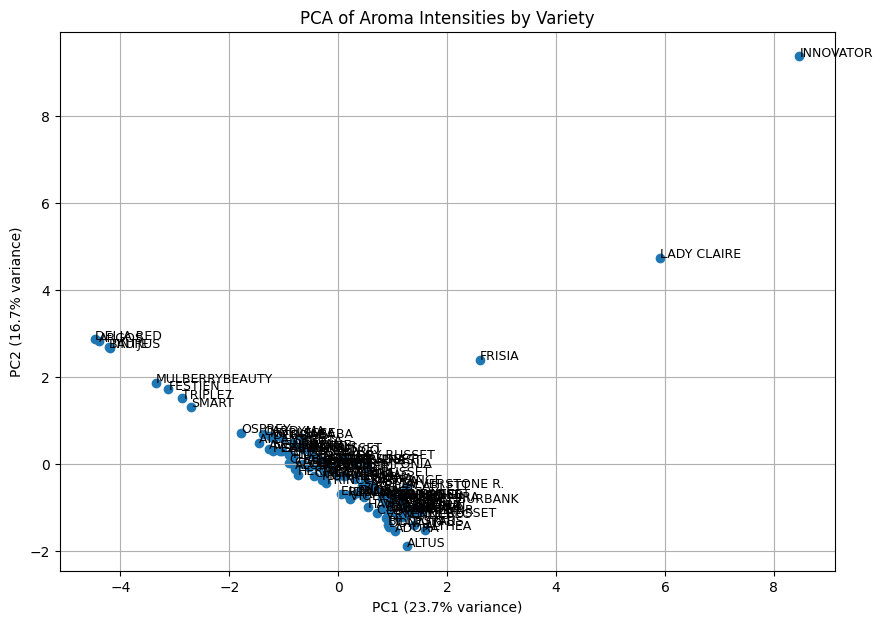

In [26]:
# If 'Variety' is a column, set it as index:
if 'Variety' in aroma_pivot_renamed.columns:
    aroma_pivot_renamed.set_index('Variety', inplace=True)

# Now extract numeric data
X_numeric = aroma_pivot_renamed.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

# Use the index (varieties) for labels
for i, variety in enumerate(aroma_pivot_renamed.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], variety, fontsize=9)

plt.xlabel('PC1 (%.1f%% variance)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%% variance)' % (pca.explained_variance_ratio_[1]*100))
plt.title('PCA of Aroma Intensities by Variety')
plt.grid(True)
plt.show()

In [27]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=aroma_pivot_renamed.columns,
    columns=['PC1','PC2']
)

# Top contributors (absolute) to each PC:
for pc in ['PC1','PC2']:
    print(pc, loadings[pc].abs().sort_values(ascending=False).head(10))


PC1 Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)    0.437942
Benzaldehyde (Almond, cherry, fruity)                      0.408805
Methional (Cooked potato, sulfurous)                       0.343439
Furfural (Sweet, almond, caramel)                          0.331980
Decanal (Citrus, floral)                                   0.318618
Butanal, 3-methyl- (Fruity, malty, chocolate)              0.302503
2,3-Butanedione (Butter, creamy, sweet)                    0.284577
Hexanal (Green, grassy)                                    0.217397
Dimethyl trisulfide (Garlic, onion, sulfurous)             0.210216
Octanal (Citrus, fruity)                                   0.140251
Name: PC1, dtype: float64
PC2 Methional (Cooked potato, sulfurous)                       0.478761
Furfural (Sweet, almond, caramel)                          0.461024
2,3-Butanedione (Butter, creamy, sweet)                    0.447512
Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)    0.297927
Benzaldehyde (

# PCA

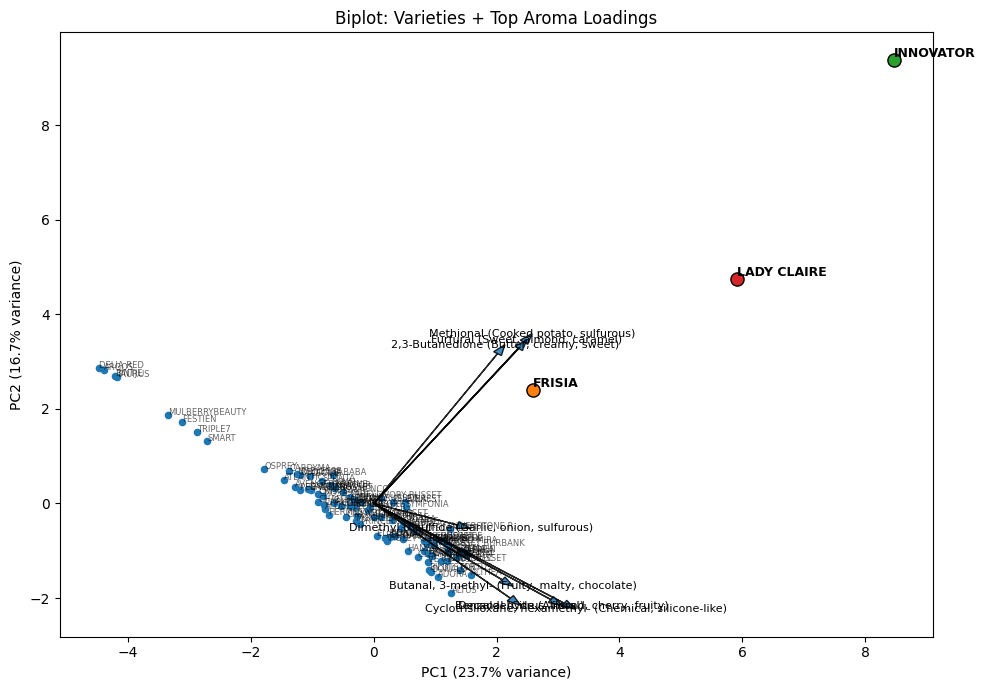

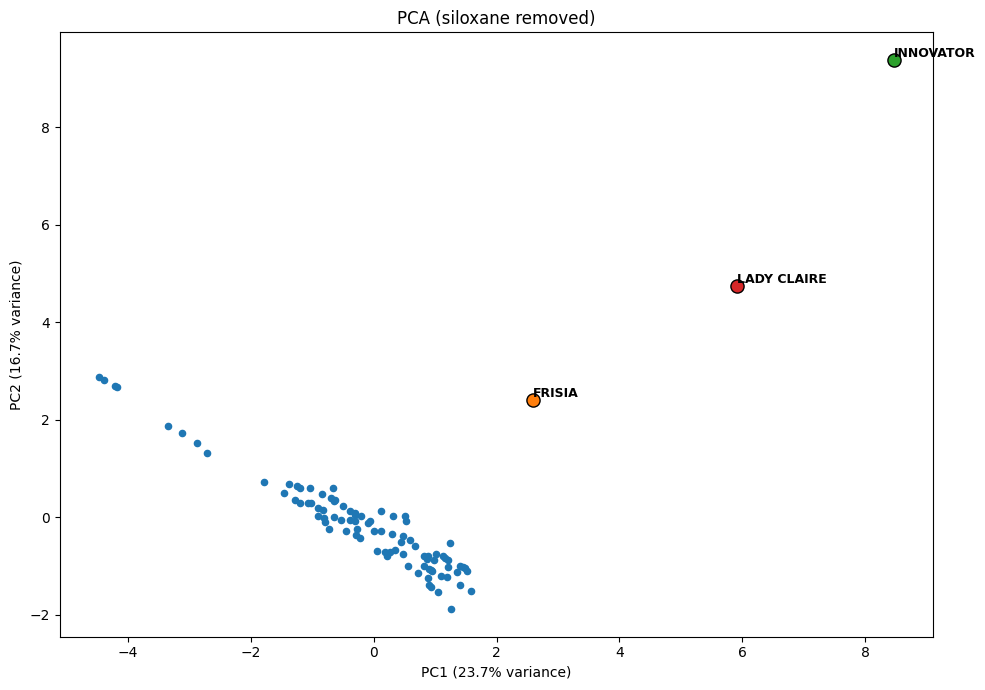


Top 10 farthest varieties (after removing siloxane):
INNOVATOR         12.638177
LADY CLAIRE        7.578308
DELIA RED          5.311601
ARGOS              5.225179
BINTJE             4.998083
TAURUS             4.972511
MULBERRYBEAUTY     3.840941
FESTIEN            3.560761
FRISIA             3.536808
TRIPLE7            3.247057
dtype: float64


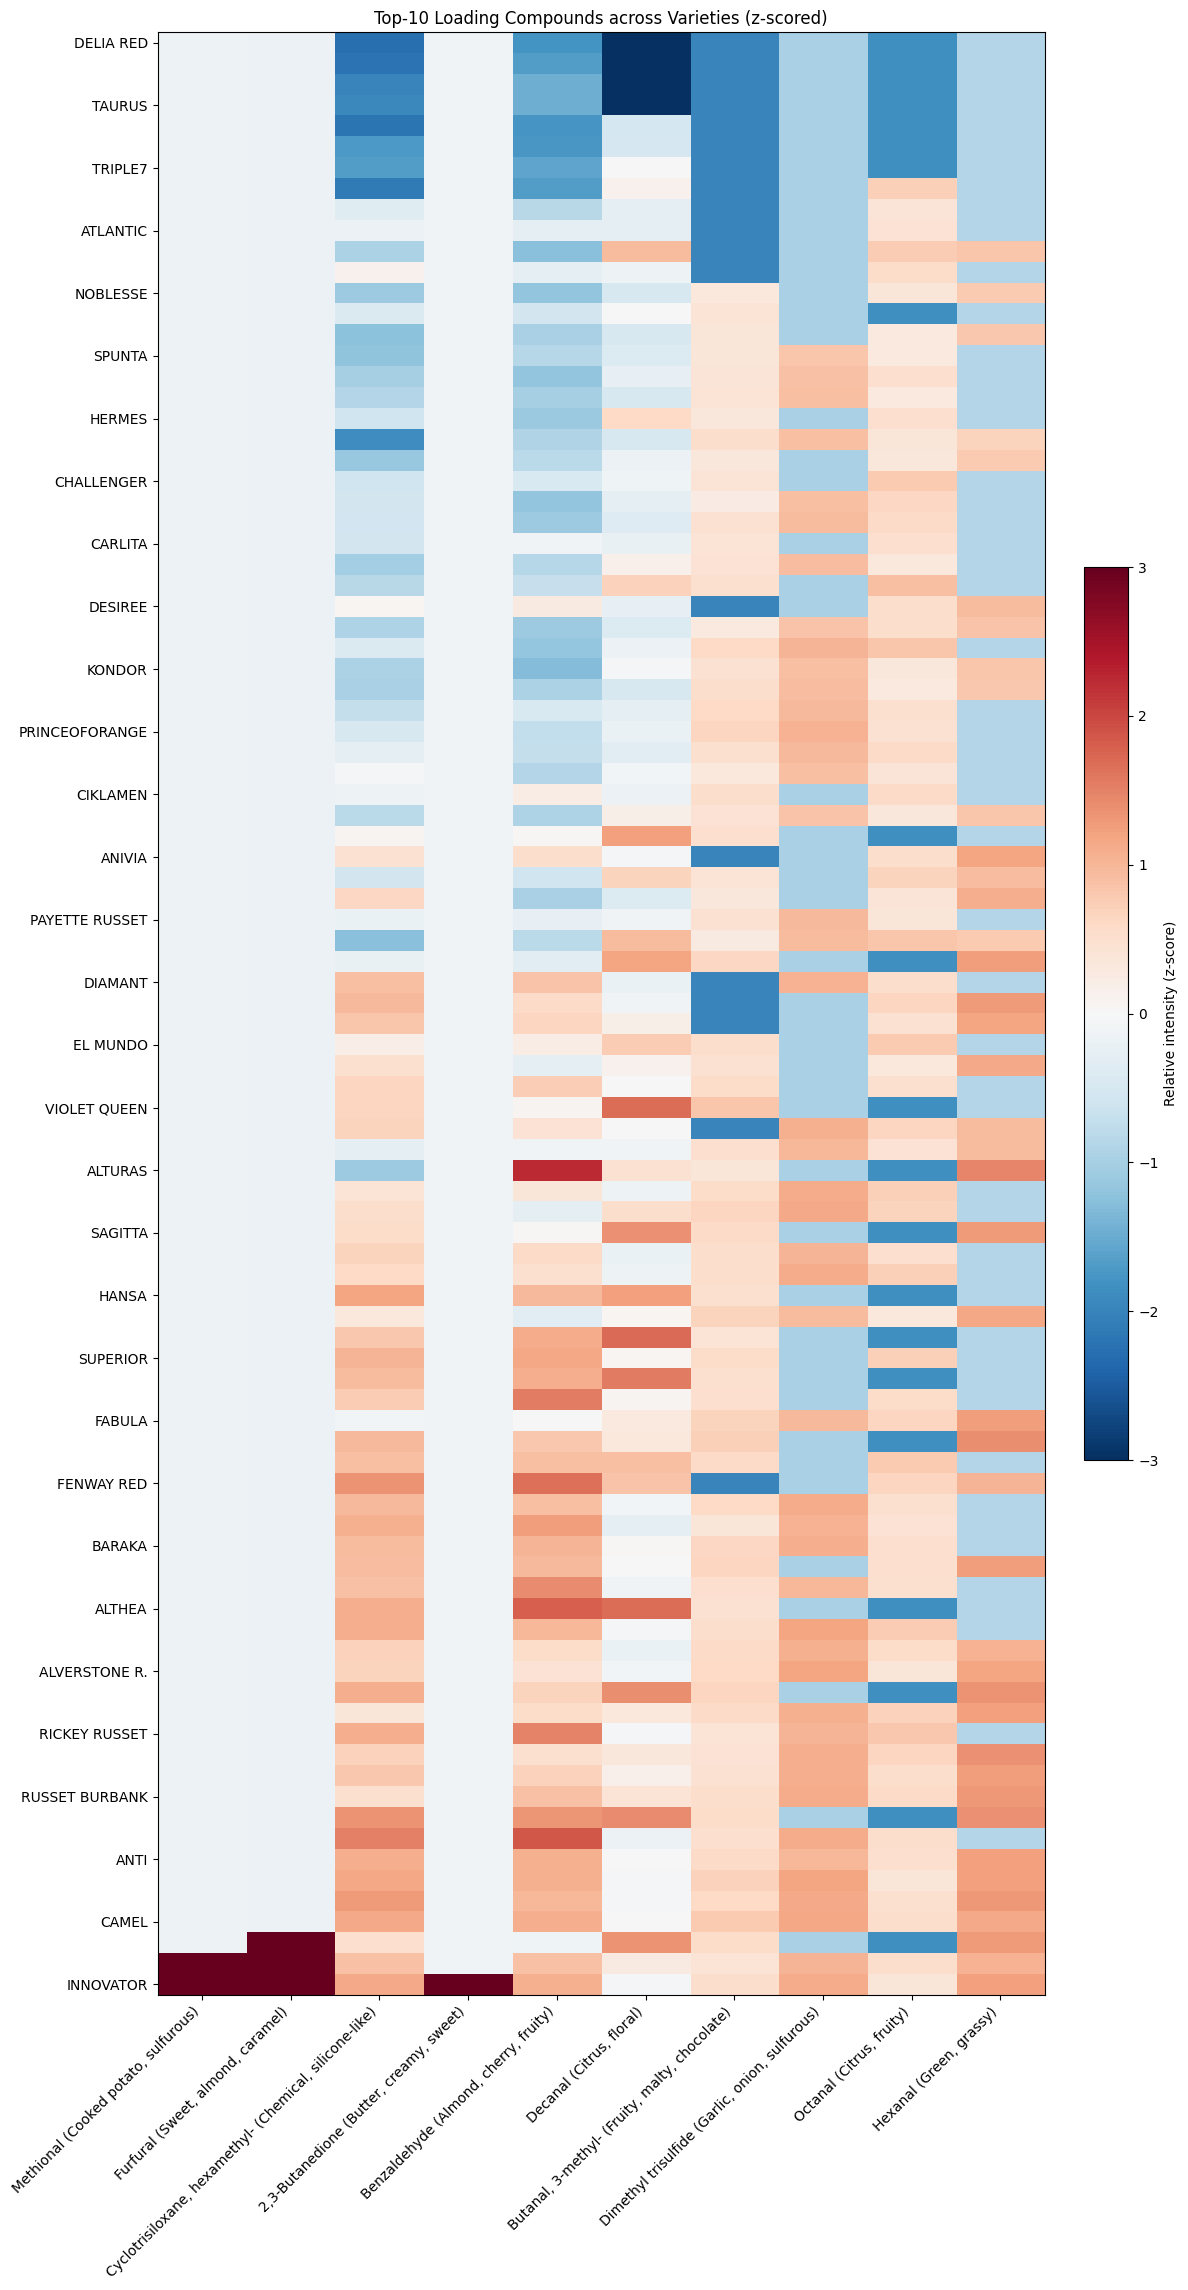

In [28]:
# PCA biplot + PCA without siloxane + Heatmap 

# I expect this table in memory: rows = Variety, columns = compounds (numerical)
assert 'aroma_pivot_renamed' in globals(), "Please define aroma_pivot_renamed first."

# PCA function (2 components)
def run_pca_2d(df):
    # standardize columns (mean=0, std=1)
    scaler = StandardScaler()
    Xz = scaler.fit_transform(df.values)

    # fit PCA with 2 components
    pca = PCA(n_components=2, random_state=0)
    scores = pca.fit_transform(Xz)  # coordinates of varieties in PC space

    # loadings = contribution of each compound to PC1 and PC2
    loadings = pd.DataFrame(pca.components_.T, index=df.columns, columns=['PC1','PC2'])
    return pca, scores, loadings

# Biplot on all compounds 
pca, scores, loadings = run_pca_2d(aroma_pivot_renamed)

plt.figure(figsize=(10,7))
plt.scatter(scores[:,0], scores[:,1], s=20)

# label a few varieties
names = aroma_pivot_renamed.index.tolist()
focus = {'INNOVATOR','LADY CLAIRE','FRISIA'}
for i, name in enumerate(names):
    if name.upper() in focus:
        plt.scatter(scores[i,0], scores[i,1], s=90, edgecolor='k')
        plt.text(scores[i,0], scores[i,1], name, fontsize=9, fontweight='bold',
                 ha='left', va='bottom')
    else:
        # small, faint labels for the rest 
        plt.text(scores[i,0], scores[i,1], name, fontsize=6, alpha=0.6)

# show arrows for top 8 compounds by |loading PC1|+|loading PC2|
topk = 8
importance = loadings.abs().sum(axis=1).sort_values(ascending=False)
top_feats = importance.head(topk).index

# scale arrows so they fit in the plot
scale = 0.8 * np.max(np.abs(scores))
for feat in top_feats:
    x = loadings.loc[feat, 'PC1'] * scale
    y = loadings.loc[feat, 'PC2'] * scale
    plt.arrow(0, 0, x, y, head_width=0.15, length_includes_head=True, alpha=0.85)
    plt.text(x, y, feat, fontsize=8, ha='center', va='center')

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Biplot: Varieties + Top Aroma Loadings")
plt.tight_layout()
plt.show()

# PCA after removing the siloxane column 
silox = "Cyclotrisiloxane, hexamethyl-"
cols_keep = [c for c in aroma_pivot_renamed.columns if c.lower() != silox.lower()]
aroma_no_silox = aroma_pivot_renamed[cols_keep]

pca2, scores2, loadings2 = run_pca_2d(aroma_no_silox)

plt.figure(figsize=(10,7))
plt.scatter(scores2[:,0], scores2[:,1], s=20)
for i, name in enumerate(names):
    if name.upper() in focus:
        plt.scatter(scores2[i,0], scores2[i,1], s=90, edgecolor='k')
        plt.text(scores2[i,0], scores2[i,1], name, fontsize=9, fontweight='bold',
                 ha='left', va='bottom')
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA (siloxane removed)")
plt.tight_layout()
plt.show()

# Simple outlier check 
dist = np.sqrt(scores2[:,0]**2 + scores2[:,1]**2)
rank = pd.Series(dist, index=names).sort_values(ascending=False)
print("\nTop 10 farthest varieties (after removing siloxane):")
print(rank.head(10))

# Heatmap for top-10 loading compounds (from the second PCA) 
top10 = loadings2.abs().sum(axis=1).sort_values(ascending=False).head(10).index
sub = aroma_no_silox[top10].copy()

# z-score each compound 
sub_z = (sub - sub.mean()) / sub.std(ddof=0)

# order rows by PC1 of the heatmap matrix 
p = PCA(n_components=2, random_state=0).fit(sub_z.values)
S = p.transform(sub_z.values)
row_order = np.argsort(S[:,0])
sub_z_ord = sub_z.iloc[row_order]

# draw heatmap with a diverging colormap and fixed limits
plt.figure(figsize=(12, max(6, int(0.25*len(sub_z_ord)))))
im = plt.imshow(sub_z_ord.values, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)

# thin out y-ticks if there are many rows
step = max(1, len(sub_z_ord)//30)
plt.yticks(np.arange(0, len(sub_z_ord), step), sub_z_ord.index[::step])

plt.xticks(np.arange(len(top10)), top10, rotation=45, ha='right')
plt.title("Top-10 Loading Compounds across Varieties (z-scored)")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Relative intensity (z-score)")
plt.tight_layout()
plt.show()


PCA: Most varieties cluster; INNOVATOR and LADY CLAIRE are clear outliers; FRISIA moderately so.

High loadings for Methional, 2,3-Butanedione, and aldehydes (Benzaldehyde/Decanal/Octanal).

Siloxane removed: Pattern stays the same → siloxane isn’t driving the main separation.

Outliers: INNOVATOR strongest; LADY CLAIRE also high; FRISIA mid.

Heatmap: Top-10 compounds show strong red/blue bands in those outliers, matching the biplot.

k=2, silhouette=0.674
k=3, silhouette=0.378
k=4, silhouette=0.280
k=5, silhouette=0.303
k=6, silhouette=0.282
Best k=2 (silhouette=0.674)


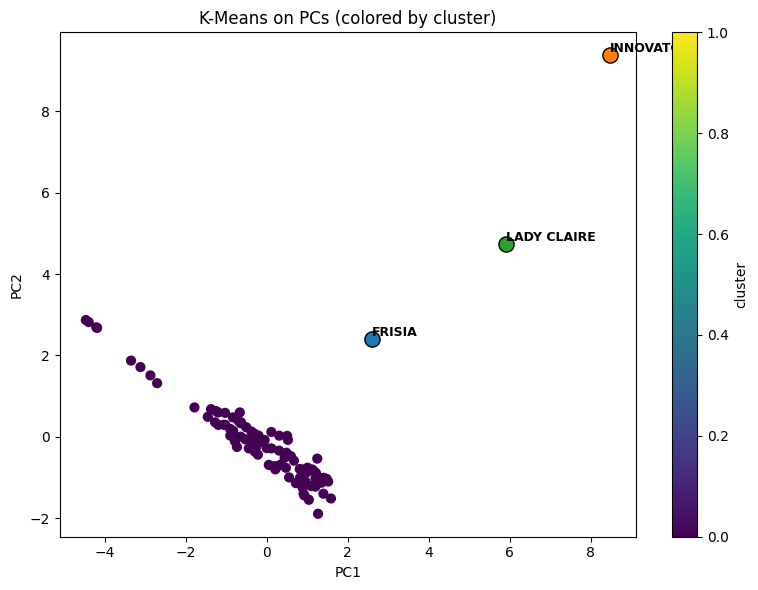

DBSCAN labels value counts: {np.int64(-1): np.int64(34), np.int64(0): np.int64(6), np.int64(1): np.int64(5), np.int64(2): np.int64(10), np.int64(3): np.int64(4), np.int64(4): np.int64(3), np.int64(5): np.int64(3), np.int64(6): np.int64(8), np.int64(7): np.int64(7), np.int64(8): np.int64(3), np.int64(9): np.int64(5), np.int64(10): np.int64(3), np.int64(11): np.int64(3)}


In [29]:

Xz = StandardScaler().fit_transform(aroma_pivot_renamed.values)
pcs = PCA(n_components=6, random_state=0).fit_transform(Xz)  # 6 فقط یک شروع خوب است

best_k, best_s, best_labels = None, -1, None
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(pcs)
    s = silhouette_score(pcs, km.labels_)
    print(f'k={k}, silhouette={s:.3f}')
    if s > best_s:
        best_k, best_s, best_labels = k, s, km.labels_

print(f'Best k={best_k} (silhouette={best_s:.3f})')

scores_2d = pcs[:, :2]
plt.figure(figsize=(8,6))
sc = plt.scatter(scores_2d[:,0], scores_2d[:,1], c=best_labels, s=40)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('K-Means on PCs (colored by cluster)')
plt.colorbar(sc, label='cluster')

names = aroma_pivot_renamed.index.to_list()
for i, name in enumerate(names):
    if name.upper() in {'INNOVATOR','LADY CLAIRE','FRISIA'}:
        plt.scatter(scores_2d[i,0], scores_2d[i,1], s=120, edgecolor='k')
        plt.text(scores_2d[i,0], scores_2d[i,1], name, fontsize=9, weight='bold',
                 ha='left', va='bottom')
plt.tight_layout(); plt.show()


db = DBSCAN(eps=0.7, min_samples=3).fit(pcs) 
labels_db = db.labels_  
print('DBSCAN labels value counts:', {l: (labels_db==l).sum() for l in np.unique(labels_db)})


Best clustering is k=2 (silhouette 0.674) → strong split.

One large core cluster and a small outlier group; INNOVATOR and LADY CLAIRE are outliers, FRISIA is borderline.

#  Statistics of aroma intensities per variety

In [30]:
# Calculate mean and std of each compound across varieties
desc_stats =aroma_pivot_renamed.describe().T  # transpose to have compounds as rows

# Show top compounds with highest mean intensity overall
top_compounds = desc_stats.sort_values(by='mean', ascending=False).head(10)
print("Top 10 aroma compounds by average intensity:")
print(top_compounds[['mean', 'std']])
aroma_pivot_renamed.head(5)


Top 10 aroma compounds by average intensity:
                                                         mean       std
Benzaldehyde (Almond, cherry, fruity)               16.398647  1.750228
Cyclotrisiloxane, hexamethyl- (Chemical, silico...  15.984822  1.582331
Decanal (Citrus, floral)                            14.820036  3.814669
Octanal (Citrus, fruity)                            13.156437  7.159785
Butanal, 3-methyl- (Fruity, malty, chocolate)       12.223914  6.220205
Dimethyl trisulfide (Garlic, onion, sulfurous)       8.927816  9.188503
Hexanal (Green, grassy)                              6.538783  7.387660
Pentanal (Green, fatty, pungent)                     3.201202  7.406310
Hexanoic acid (Fatty, cheesy, sweaty)                3.034014  7.384243
Furfural (Sweet, almond, caramel)                    0.443991  2.460374


,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
Variety,,,,,,,,,,,,,
ADORA,0.0,0.0,17.984870,15.836435,17.417208,18.203338,0.00000,0.0,0.00000,22.334351,0.0,18.799602,0.000000
AGRIA,0.0,0.0,14.859493,14.154847,15.947810,14.499810,17.21077,0.0,0.00000,0.000000,0.0,15.924101,18.039118
ALOUETTE,0.0,0.0,15.205705,15.262178,14.678352,17.462371,0.00000,0.0,0.00000,0.000000,0.0,19.520823,0.000000
ALTHEA,0.0,0.0,19.535081,14.984406,17.704453,21.158234,0.00000,0.0,0.00000,18.548808,0.0,0.000000,20.209723
ALTURAS,0.0,0.0,20.293776,14.482897,14.257052,16.590508,0.00000,0.0,17.24572,0.000000,0.0,0.000000,0.000000


Overall, aldehydes (benzaldehyde, decanal, octanal) dominate the average aroma signal across varieties.

# Cluster Analysis

Number of unique varieties: 94
Some varieties: ['ADORA', 'AGRIA', 'ALOUETTE', 'ALTHEA', 'ALTURAS', 'ALTUS', 'ALVERSTONE R.', 'ANIVIA', 'ANTI', 'ARDECHE']


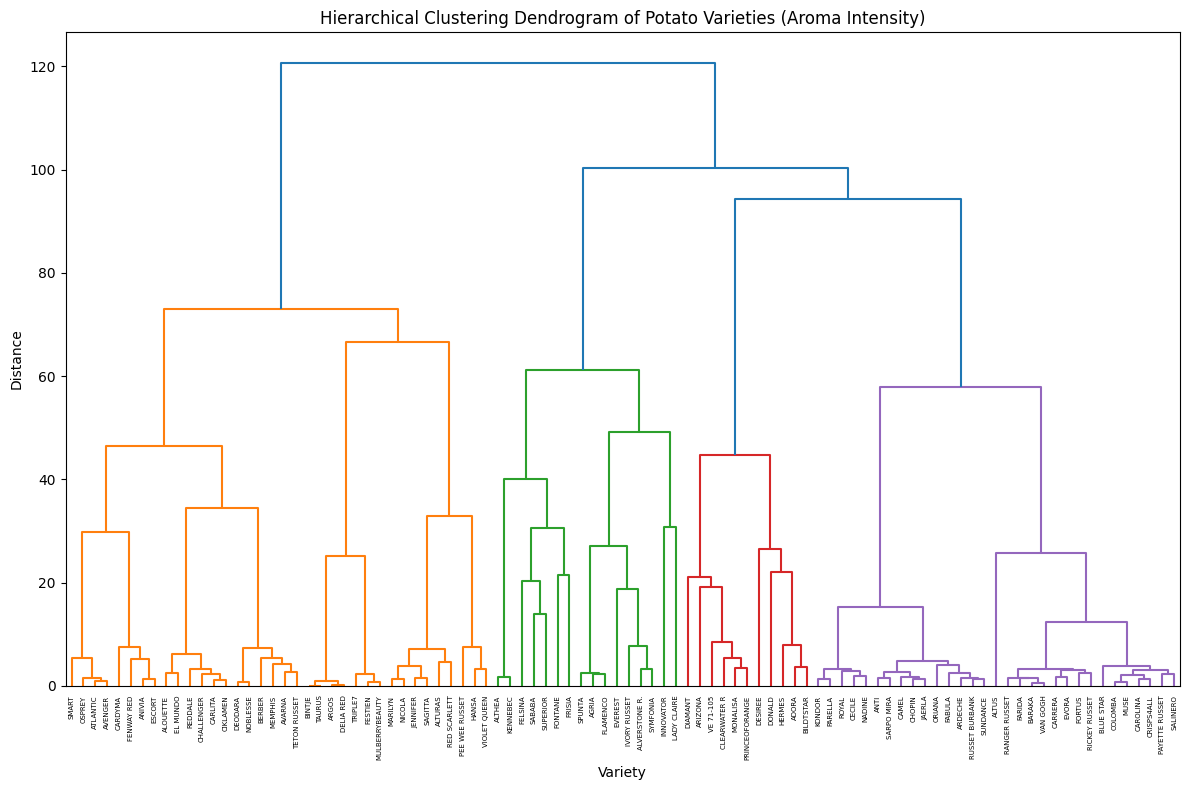

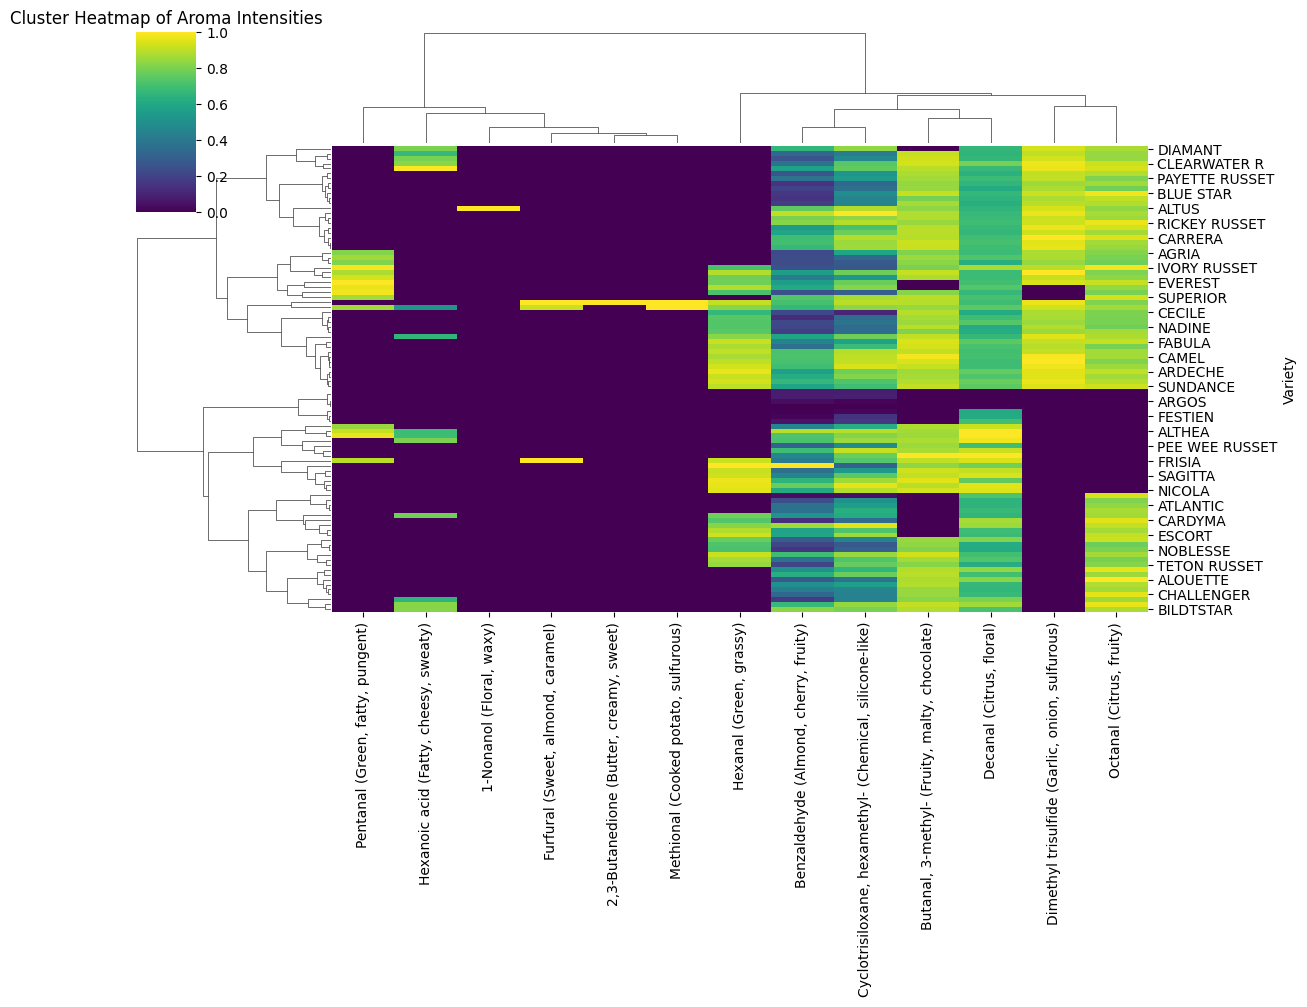

In [31]:
# Number of unique varieties 
num_varieties = aroma_pivot_renamed.index.nunique()
print(f"Number of unique varieties: {num_varieties}")

#see the first few variety names
print("Some varieties:", aroma_pivot_renamed.index[:10].tolist())

# Compute linkage matrix for hierarchical clustering (using Ward's method)
Z = linkage(aroma_pivot_renamed, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(Z, labels=aroma_pivot_renamed.index, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram of Potato Varieties (Aroma Intensity)')
plt.xlabel('Variety')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

#Cluster heatmap (combines dendrogram + heatmap)
sns.clustermap(aroma_pivot_renamed, method='ward', figsize=(12, 10), cmap='viridis', standard_scale=1)
plt.title('Cluster Heatmap of Aroma Intensities')
plt.show()


This heatmap helps identify which aroma compounds drive the differences between potato varieties.

Some varieties are sulfur-rich (strong cooked/onion notes).

Some are fruity/citrus-like.

Some are sweet/caramelized.

some aldehydes (e.g., benzaldehyde/decanal/octanal) and sulfur notes (e.g., DMTS/methional) are bright/dark together within clusters, indicating they help drive the separation.


In [34]:
from scipy.spatial.distance import pdist, squareform

# drop siloxanes 
X = aroma_pivot_renamed.loc[:, ~aroma_pivot_renamed.columns.str.contains("siloxan", case=False)].copy()
#z-score columns
Xz = (X - X.mean()) / X.std(ddof=0)
Xz = Xz.fillna(0)

# Euclidean distances on standardized data
D = squareform(pdist(Xz.values, metric='euclidean'))
dist_matrix = pd.DataFrame(D, index=X.index, columns=X.index)

upper = dist_matrix.where(np.triu(np.ones(dist_matrix.shape), k=1).astype(bool))

pairs = (
    upper
      .stack(dropna=True)                        # Series with MultiIndex
      .rename_axis(index=['Variety1','Variety2'])# give index levels clear names
      .reset_index(name='Distance')              # avoid the column-name collision
)

print("Top 5 most similar:")
print(pairs.nsmallest(5, 'Distance'))

print("\nTop 5 most different:")
print(pairs.nlargest(5, 'Distance'))



Top 5 most similar:
     Variety1        Variety2  Distance
1590   BINTJE          TAURUS  0.007526
3211  FESTIEN  MULBERRYBEAUTY  0.039137
906     ARGOS       DELIA RED  0.127825
2063   CECILE          NADINE  0.165002
1365   BARAKA        VAN GOGH  0.165126

Top 5 most different:
       Variety1   Variety2   Distance
501       ALTUS  INNOVATOR  16.628461
2499  DELIA RED  INNOVATOR  14.829529
926       ARGOS  INNOVATOR  14.805481
1554     BINTJE  INNOVATOR  14.771055
3545  INNOVATOR     TAURUS  14.769768


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_1272\1012409339.py:17: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)                        # Series with MultiIndex


# Determine the relative concentration of aroma compounds 

In [35]:

#average intensity per Variety and Compound
aroma_summary = aroma_per_variety.groupby(['Variety', 'norm_name'])['Intensity'].mean().unstack(fill_value=0)


In [36]:
relative_conc = aroma_summary.div(aroma_summary.sum(axis=1), axis=0)
relative_conc

norm_name,1nonanol,23pentanedione,9hexadecenoicacid,benzaldehyde,butanal3methyl,cyclotrisiloxanehexamethyl,decanal,dimethyltrisulfide,dodecanal,furfural,hexanal,methional,ndecanoicacid,nhexadecanoicacid,octanal,pentanal,tridecanal,undecanal
Variety,,,,,,,,,,,,,,,,,,
ADORA,0.0,0.0,0.000000,0.139657,0.122974,0.135249,0.110873,0.000000,0.171834,0.0,0.000000,0.0,0.0,0.173431,0.145983,0.000000,0.0,0.0
AGRIA,0.0,0.0,0.000000,0.134310,0.127941,0.144147,0.131059,0.155562,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.143932,0.163049,0.0,0.0
ALOUETTE,0.0,0.0,0.000000,0.152680,0.153247,0.147385,0.150680,0.000000,0.199999,0.0,0.000000,0.0,0.0,0.000000,0.196008,0.000000,0.0,0.0
ALTHEA,0.0,0.0,0.000000,0.174202,0.133621,0.157877,0.188676,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.165407,0.000000,0.180218,0.0,0.0
ALTURAS,0.0,0.0,0.000000,0.244887,0.174767,0.172041,0.200199,0.000000,0.000000,0.0,0.208106,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TETON RUSSET,0.0,0.0,0.000000,0.164036,0.159237,0.189085,0.147464,0.000000,0.000000,0.0,0.162115,0.0,0.0,0.000000,0.178063,0.000000,0.0,0.0
TRIPLE7,0.0,0.0,0.000000,0.326468,0.000000,0.319531,0.354001,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
VAN GOGH,0.0,0.0,0.000000,0.176964,0.157068,0.172626,0.143291,0.187280,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.162772,0.000000,0.0,0.0


Interactive Analysis of Aroma Compounds Across Potato Varieties

In [37]:


def make_relative(df: pd.DataFrame) -> pd.DataFrame:
    denom = df.sum(axis=1).replace(0, np.nan)
    rel = df.div(denom, axis=0).fillna(0)
    return rel

def clr_transform_from_relative(rel: pd.DataFrame, pseudo: float = 1e-6) -> pd.DataFrame:
    rel_pc = rel + pseudo
    log = np.log(rel_pc)
    clr = log.sub(log.mean(axis=1), axis=0)
    return clr

def clr_transform_from_raw(df_raw: pd.DataFrame, pseudo: float = 1e-6) -> pd.DataFrame:
    rel = make_relative(df_raw)
    return clr_transform_from_relative(rel, pseudo=pseudo)

def is_siloxane(name: str) -> bool:
    s = str(name).lower()
    return any(k in s for k in ("siloxan", "cyclotri", "cyclotetra", "cyclopenta"))

def wrap_label(s, width=14):
    s = str(s)
    return "<br>".join(s[i:i+width] for i in range(0, len(s), width))

def abbrev_labels(labels, width=14):
    return [wrap_label(x, width) for x in labels]

def safe_zscore(df):
    mu = df.mean(axis=0)
    sd = df.std(axis=0, ddof=0).replace(0, np.nan)
    z = (df - mu) / sd
    return z.fillna(0)

def top_pca_features(df, n=18):
    """Return top-n features by loading on PC1/PC2."""
    pca = PCA(n_components=2)
    X = df.values
    pca.fit(X)
    loadings = pd.DataFrame(
        pca.components_.T,
        index=df.columns,
        columns=["PC1","PC2"]
    )
    scores = loadings.abs().sum(axis=1)   # total importance
    return scores.sort_values(ascending=False).head(n).index.tolist()


if 'relative_conc' in globals():
    BASE_REL = relative_conc.copy()
    BASE_RAW = None


BASE_REL = BASE_REL.copy()
BASE_REL.index = BASE_REL.index.astype(str)
BASE_REL.columns = [str(c) for c in BASE_REL.columns]
if BASE_RAW is not None:
    BASE_RAW = BASE_RAW.copy()
    BASE_RAW.index = BASE_RAW.index.astype(str)
    BASE_RAW.columns = [str(c) for c in BASE_RAW.columns]


# Dash app
app = Dash(__name__)

variety_options = [{"label": v, "value": v} for v in sorted(BASE_REL.index)]
default_variety = variety_options[0]["value"]
max_topn = min(40, BASE_REL.shape[1])

app.layout = html.Div(
    style={"fontFamily": "system-ui, Segoe UI, Roboto, Arial, sans-serif", "padding": "12px"},
    children=[
        html.H3("Potato Aroma Dashboard"),
        html.Div([
            html.Label("Data mode"),
            dcc.RadioItems(
                id="mode",
                options=[
                    {"label": "Relative", "value": "REL"},
                    {"label": "CLR", "value": "CLR"},
                ],
                value="REL",
                inline=True,
            ),
            html.Br(),
            html.Label("Feature selection"),
            dcc.RadioItems(
                id="feature_mode",
                options=[
                    {"label": "Top Variance", "value": "VAR"},
                    {"label": "Top PCA loadings", "value": "PCA"},
                ],
                value="VAR",
                inline=True,
            ),
        ], style={"marginBottom": "10px"}),

        html.Div(
            style={"display": "grid", "gridTemplateColumns": "1fr 1fr", "gap": "12px"},
            children=[
                html.Div([
                    html.Label("Variety"),
                    dcc.Dropdown(options=variety_options, value=default_variety, id="variety"),
                    html.Br(),
                    html.Label("Top-N compounds (bar)"),
                    dcc.Slider(
                        id="topn", min=5, max=max_topn, step=1, value=min(15, max_topn),
                        marks=None, tooltip={"placement":"bottom", "always_visible": True}
                    ),
                    html.Br(),
                    dcc.Checklist(
                        id="opts",
                        options=[
                            {"label": "Exclude siloxanes", "value": "nosilox"},
                            {"label": "Compact labels", "value": "compact"},
                        ],
                        value=["nosilox", "compact"],
                    ),
                    dcc.Graph(id="bar_profile", config={"displayModeBar": False}, style={"height": "420px"}),
                ]),
                html.Div([
                    html.Label("Overview Heatmap"),
                    html.Div([
                        html.Label("Heatmap rows (varieties shown)"),
                        dcc.Slider(
                            id="heat_rows", min=10, max=min(60, len(BASE_REL)), step=1,
                            value=min(35, len(BASE_REL)),
                            marks=None, tooltip={"placement":"bottom", "always_visible": True}
                        ),
                    ], style={"marginBottom": "6px"}),
                    dcc.Graph(id="heatmap", config={"displayModeBar": False}, style={"height": "520px"}),
                ]),
            ],
        ),
    ],
)

@app.callback(
    Output("bar_profile", "figure"),
    Output("heatmap", "figure"),
    Input("mode", "value"),
    Input("feature_mode", "value"),
    Input("variety", "value"),
    Input("topn", "value"),
    Input("opts", "value"),
    Input("heat_rows", "value"),
)
def update_dashboard(mode, feature_mode, variety, topn, opts, heat_rows):
    if variety is None:
        return no_update, no_update

    opts = opts or []

    # choose matrix
    if mode == "REL":
        base = BASE_REL
        ylab_bar = "Relative Conc."
        title_suffix = "Relative"
    else:
        if 'relative_conc' in globals():
            clr = clr_transform_from_relative(BASE_REL)
        else:
            clr = clr_transform_from_raw(BASE_RAW)
        base = clr
        ylab_bar = "CLR score"
        title_suffix = "CLR"

    cols = [c for c in base.columns if ("nosilox" not in opts or not is_siloxane(c))]
    df = base[cols]

    # Bar chart
    s = df.loc[variety].sort_values(ascending=False).head(int(topn))
    x_vals = s.index.tolist()
    bar = go.Figure([go.Bar(x=x_vals, y=s.values.tolist(), name=variety)])
    if "compact" in opts:
        bar.update_xaxes(tickmode="array", tickvals=x_vals, ticktext=abbrev_labels(x_vals, width=14))
        xangle = 0
    else:
        xangle = -45
    bar.update_layout(
        title=f"{title_suffix} Profile — {variety} (Top {len(s)})",
        xaxis_title="Aroma Compounds",
        yaxis_title=ylab_bar,
        xaxis={"tickangle": xangle},
        margin=dict(l=60, r=20, t=60, b=120),
        height=420,
    )

    # Heatmap feature selection 
    if feature_mode == "VAR":
        var_by_comp = df.var(axis=0).sort_values(ascending=False)
        top_cols = var_by_comp.index[:18].tolist()
        feature_title = "High-Variance"
    else:
        top_cols = top_pca_features(df, n=18)
        feature_title = "Top PCA loadings"

    Z = safe_zscore(df[top_cols])
    rows = sorted(Z.index.tolist())[:int(heat_rows)]
    Z_small = Z.loc[rows]

    heat = go.Figure(data=go.Heatmap(
        z=Z_small.values,
        x=top_cols,
        y=rows,
        colorscale="Viridis",
    ))
    if "compact" in opts:
        heat.update_xaxes(tickmode="array", tickvals=top_cols, ticktext=abbrev_labels(top_cols, width=12))
    heat.update_layout(
        title=f"Heatmap ({feature_title}, {title_suffix}; first {len(rows)} varieties)",
        xaxis_title="Aroma Compounds",
        yaxis_title="Variety",
        margin=dict(l=90, r=20, t=60, b=120),
        height=520,
    )

    return bar, heat

# run
try:
    app.run(debug=False, jupyter_mode="inline", use_reloader=False)
except TypeError:
    app.run(debug=False, host="127.0.0.1", port=8050, use_reloader=False)


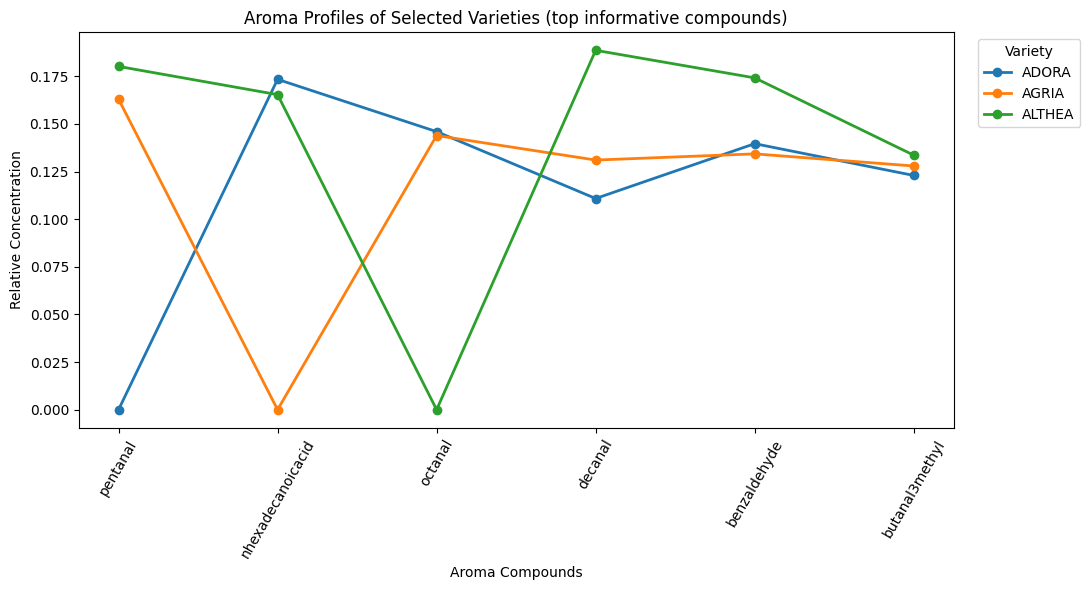

In [38]:
selected = ['ADORA','AGRIA','ALTHEA']
df = relative_conc.copy()
df.index = df.index.astype(str).str.upper()

# pick rows and drop siloxanes
rows = [v for v in map(str.upper, selected) if v in df.index]
X = df.loc[rows]
X = X.loc[:, ~X.columns.str.contains(r"siloxan|cyclotri|cyclotetra|cyclopenta", case=False)]

# keep compounds non-zero in at least 2 varieties, top 12 by variance
keep = (X.astype(bool).sum(axis=0) >= 2)
cols = X.loc[:, keep].var(axis=0).sort_values(ascending=False).head(12).index
X = X[cols]

# plot (one call, tidy legend)
ax = X.T.plot(figsize=(11,6), lw=2, marker='o')
ax.set_title("Aroma Profiles of Selected Varieties (top informative compounds)")
ax.set_xlabel("Aroma Compounds"); ax.set_ylabel("Relative Concentration")
ax.legend(title="Variety", bbox_to_anchor=(1.02,1), loc="upper left")
ax.tick_params(axis='x', labelrotation=60)
plt.tight_layout(); plt.show()


ALTHEA → stands out for high decanal and benzaldehyde (citrus/fruity), also high pentanal; octanal is near zero.

AGRIA → highest pentanal and strong octanal; almost no hexadecanoic acid.

ADORA → highest hexadecanoic acid; moderate benzaldehyde/octanal; very low pentanal.

Butanal, 3-methyl is similar across the three (small differences).

# joining the sensory panel data 

In [39]:
sensory = pd.read_excel(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx")
print(sensory.columns)
sensory.head()

Index(['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour',
       'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness',
       'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes',
       'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma',
       'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
       'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour',
       'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour',
       'Sweet Flavour', 'Root/ Vegetable Flavour',
       'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel',
       'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh',
       'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin',
       'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste',
       'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47',
       'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK',
       'cluster 3 Sp, clu

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Cleaning of sensory dataset 

In [ ]:
# flavor-related columns
FLAVOR_COLS = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste"
]


sensory['VARIETY'] = sensory['VARIETY'].astype(str).str.strip()

# Drop any unnamed columns
sensory = sensory.drop(columns=[c for c in sensory.columns if str(c).startswith('Unnamed')], errors='ignore')

#  Coerce numerics & groupby mean per variety 
sensory_traits = sensory[FLAVOR_COLS].apply(pd.to_numeric, errors='coerce')
sensory_traits = sensory_traits.assign(VARIETY=sensory['VARIETY'])

sensory_summary = (
    sensory_traits
    .groupby('VARIETY', as_index=False)
    .mean(numeric_only=True)
)

print("Rows (varieties):", sensory_summary['VARIETY'].nunique())
print("Traits averaged:", len(FLAVOR_COLS))
print("First rows:")
print(sensory_summary.head())


Rows (varieties): 59
Traits averaged: 11
First rows:
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  Sour Aftertaste  \
0                        12.520             15.647  

# predicting the flavors for all the non existing varaieties by using the aroma compounds

In [41]:
aroma_df = aroma_pivot_renamed.reset_index()
aroma_df.rename(columns={'index': 'Variety'}, inplace=True)
sensory_summary.rename(columns={'VARIETY': 'Variety'}, inplace=True)

# Now both dataframes have 'Variety' column

# Clean whitespace 
for df in [aroma_df, sensory_summary]:
    df['Variety'] = df['Variety'].astype(str).str.strip().str.upper()

# Merge on 'Variety'
merged_aroma_sensory = pd.merge(aroma_df, sensory_summary, on='Variety', how='inner')

print(f"Number of merged varieties: {merged_aroma_sensory['Variety'].nunique()}")
print(merged_aroma_sensory.head())

merged_aroma_sensory.to_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\merged_aroma_sensory.csv', index=False)


Number of merged varieties: 20
     Variety  1-Nonanol (Floral, waxy)  \
0      ADORA                       0.0   
1      AGRIA                       0.0   
2     BERBER                       0.0   
3  BILDTSTAR                       0.0   
4     BINTJE                       0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   Benzaldehyde (Almond, cherry, fruity)  \
0                              17.984870   
1                              14.859493   
2                              15.354625   
3                              19.062354   
4                              13.831978   

   Butanal, 3-methyl- (Fruity, malty, chocolate)  \
0                                      15.836435   
1                                      14.154847   
2                 

Variety-Indexed Aroma–Sensory Data Alignment Pipeline

In [ ]:
def ensure_variety_index(df):
    # Ensure DataFrame has 'Variety' as uppercase-stripped index.
    df = df.copy()
    if 'Variety' in df.columns:
        df = df.dropna(subset=['Variety']).set_index('Variety')
    else:
        cand = [c for c in df.columns if str(c).strip().lower() == 'variety']
        if cand:
            df = df.dropna(subset=[cand[0]]).set_index(cand[0])
    df.index = df.index.astype(str).str.strip().str.upper()
    df.index.name = 'Variety'
    return df

# Aroma features (compounds)
compound_matrix = ensure_variety_index(aroma_pivot_renamed)
compound_matrix.columns = [str(c).strip() for c in compound_matrix.columns]
compound_matrix = compound_matrix.apply(pd.to_numeric, errors="coerce")
compound_matrix = compound_matrix.loc[:, compound_matrix.notna().any(axis=0)]

# Sensory labels 
ms = ensure_variety_index(merged_aroma_sensory)

if isinstance(FLAVOR_COLS, list):
    df0 = ms[FLAVOR_COLS].copy()
else:
    df0 = ensure_variety_index(FLAVOR_COLS)

# safe feature names 
pretty = pd.Series(compound_matrix.columns, index=compound_matrix.columns)
safe = pretty.str.replace(r"[^0-9A-Za-z]+", "_", regex=True).str.strip("_")
name_map_safe2pretty = dict(zip(safe, pretty))

X = compound_matrix.copy()
X.columns = safe

#Align on  varieties 
common = X.index.intersection(df0.index)
X = X.loc[common].copy()
df0 = df0.loc[common].copy()

print("Aligned shapes:")
print("  X   :", X.shape)
print("  df0 :", df0.shape)
print("First few varieties:", X.index[:5].tolist())


Aligned shapes:
  X   : (20, 13)
  df0 : (20, 11)
First few varieties: ['ADORA', 'AGRIA', 'BERBER', 'BILDTSTAR', 'BINTJE']


LOOCV-Optimized PLSR for Flavor Trait Prediction

In [58]:


try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

assert 'X' in globals(), "X (features) must be defined as a DataFrame with Variety index."
assert isinstance(X, pd.DataFrame)

#  Helpers 
def canon_var(s: str) -> str:
    """Normalize variety names for consistent matching."""
    return re.sub(r"\s+", " ", str(s).strip().upper())

def norm_col(s: str) -> str:
    """Normalize sensory column headers for regex matching."""
    s = str(s).strip().lower().replace("flavour", "flavor")
    return re.sub(r"[^a-z0-9]+", "", s)

def rmse_metric(y_true, y_pred):
    """Backward-compatible RMSE."""
    try:
        return mean_squared_error(y_true, y_pred, squared=False)  # newer sklearn
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))        # older sklearn

def make_pls(k=2):
    """Leak-free PLS pipeline (no double scaling)."""
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, validate=False)),
        ("sc", StandardScaler()),
        ("pls", PLSRegression(n_components=k, scale=False)),
    ])

# Final canonical flavor columns we want
FLAVOR_COLS = [
    'Metallic Flavour','Bitter Flavour','Earthy Flavour','Sour Flavour',
    'Fresh Flavour','Sweet Flavour','Root/ Vegetable Flavour',
    'Farmyard (grass/hay) flavour','Bitter Aftertaste','Sour Aftertaste','Sweet Aftertaste'
]

# Regex map
CANON = {
    "Metallic Flavour":               [r"metallic"],
    "Bitter Flavour":                 [r"^bitter(?!aftertaste)"],
    "Earthy Flavour":                 [r"earthy|earthyaroma"],
    "Sour Flavour":                   [r"^sour(?!aftertaste)"],
    "Fresh Flavour":                  [r"fresh"],
    "Sweet Flavour":                  [r"^sweet(?!aftertaste)"],
    "Root/ Vegetable Flavour":        [r"root|vegetable"],
    "Farmyard (grass/hay) flavour":   [r"farmyard|grass|hay"],
    "Bitter Aftertaste":              [r"bitter.*aftertaste|aftertaste.*bitter"],
    "Sour Aftertaste":                [r"sour.*aftertaste|aftertaste.*sour"],
    "Sweet Aftertaste":               [r"sweet.*aftertaste|aftertaste.*sweet"],
}

# 
SENSORY_PATHS = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx"
]
sensory = None
for p in SENSORY_PATHS:
    if os.path.exists(p):
        sensory = pd.read_excel(p)
        print("Loaded sensory:", p)
        break

# Find variety column
var_candidates = [c for c in sensory.columns if str(c).strip().upper() in
                  {"VARIETY","VARIETIES","SAMPLE","SAMPLE NAME","SAMPLENAME","VARIETY NAME"}]

var_col = var_candidates[0]

# Map messy headers -> canonical names
sens_cols = [c for c in sensory.columns if c != var_col]
nmap = {c: norm_col(c) for c in sens_cols}
colmap = {}  # original col -> canonical name
for canon_name, pats in CANON.items():
    for c in sens_cols:
        nc = nmap[c]
        if all(re.search(p, nc) is not None for p in pats):
            colmap[c] = canon_name
            # keep first matched column per canonical name
            break

# Keep only mapped columns
keep = [var_col] + list(colmap.keys())
df0 = sensory[keep].copy().rename(columns={var_col: "Variety", **colmap})
df0["Variety"] = df0["Variety"].map(canon_var)

# Coerce numeric 
for c in colmap.values():
    if c in df0.columns:
        df0[c] = (df0[c].astype(str)
                        .str.replace(",", ".", regex=False)
                        .str.replace(r"[^\d\.\-eE]+", "", regex=True))
        df0[c] = pd.to_numeric(df0[c], errors="coerce")

# Average replicates by Variety
df0 = df0.groupby("Variety", as_index=True).mean(numeric_only=True)

# Targets available
targets = [t for t in FLAVOR_COLS if t in df0.columns]
missing = [t for t in FLAVOR_COLS if t not in df0.columns]
print("Targets to model:", targets)
if missing:
    print("Missing (not numeric / not found):", missing)


# Do NOT globally align X to df0; we want predictions for all varieties.
X_all = X.copy()
X_all.index = X_all.index.map(canon_var)

# ----------------- Train per target on labeled intersection -----------------
pred_cols, cal_cols = {}, {}
metrics_rows = []

for tgt in targets:
    y = df0[tgt].dropna()
    if y.empty:
        continue

    # Train only on labeled intersection
    train_idx = X_all.index.intersection(y.index)
    if len(train_idx) < 3:
        print(f"Skip {tgt}: too few labeled varieties ({len(train_idx)}).")
        continue

    X_lab, y_lab = X_all.loc[train_idx], y.loc[train_idx].astype(float)

    # Fit PLS (k=2 by default — adjust if you later optimize k)
    pipe = make_pls(k=2).fit(X_lab, y_lab)

    # Predict for ALL varieties (raw)
    raw = pipe.predict(X_all).ravel()
    pred_cols[f"{tgt}__pred"] = raw

    # Evaluation via LOOCV on labeled set 
    yhat_cv = cross_val_predict(pipe, X_lab, y_lab, cv=LeaveOneOut(), n_jobs=-1).ravel()

    rho,  _ = spearmanr(y_lab.values, yhat_cv)
    pr,   _ = pearsonr(y_lab.values, yhat_cv)
    r2       = r2_score(y_lab.values, yhat_cv)
    mae      = mean_absolute_error(y_lab.values, yhat_cv)
    rmse     = rmse_metric(y_lab.values, yhat_cv)

    # Calibration
    A = np.vstack([np.ones_like(yhat_cv), yhat_cv]).T
    a, b = np.linalg.lstsq(A, y_lab.values, rcond=None)[0]

    # Isotonic calibration 
    if len(y_lab) >= 6:
        iso = IsotonicRegression(out_of_bounds='clip').fit(yhat_cv, y_lab.values)
        cal = iso.transform(raw)
        cal_cols[f"{tgt}__pred_cal"] = cal

    # Store metrics row
    metrics_rows.append({
        "target": tgt,
        "n_labels": int(len(y_lab)),
        "R2_cv": float(r2),
        "Spearman_cv": float(rho) if not np.isnan(rho) else np.nan,
        "Pearson_cv": float(pr) if not np.isnan(pr) else np.nan,
        "MAE_cv": float(mae),
        "RMSE_cv": float(rmse),
        "Cal_intercept": float(a),
        "Cal_slope": float(b),
    })


OUTPUT_DIR = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Evaluation summary
cv_summary = pd.DataFrame(metrics_rows).sort_values("R2_cv", ascending=False)
cv_summary_path = os.path.join(OUTPUT_DIR, "plsr_loocv_eval_summary.csv")
cv_summary.to_csv(cv_summary_path, index=False)
print(f"Saved: {cv_summary_path}")

# Predictions 
pred_all = pd.DataFrame(index=X_all.index, data={**pred_cols, **cal_cols}) \
            .reset_index().rename(columns={"index": "Variety"})
pred_all_path = os.path.join(OUTPUT_DIR, "rankfirst_predictions_all_varieties_CALIBRATED.csv")
pred_all.to_csv(pred_all_path, index=False)

# Unlabeled-only predictions 
labeled_set = set(df0.index)
pred_unlabeled = pred_all[~pred_all['Variety'].isin(labeled_set)].copy()
pred_unlabeled_path = os.path.join(OUTPUT_DIR, "flavor_predictions_unlabeled_74.csv")
pred_unlabeled.to_csv(pred_unlabeled_path, index=False)


display(cv_summary.head(10))
print(pred_all.head())


Loaded sensory: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx
Targets to model: ['Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Bitter Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste']
Saved: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\plsr_loocv_eval_summary.csv


,target,n_labels,R2_cv,Spearman_cv,Pearson_cv,MAE_cv,RMSE_cv,Cal_intercept,Cal_slope
9,Sour Aftertaste,20,-0.257495,0.293233,0.178103,1.638119,2.298597,5.406266,0.248816
1,Bitter Flavour,20,-0.360390,0.170741,0.062168,1.982239,2.745652,6.918011,0.093407
10,Sweet Aftertaste,20,-0.410414,0.097744,0.050645,1.659006,2.100725,2.940576,0.073168
6,Root/ Vegetable Flavour,20,-0.436528,0.203008,0.220352,2.080511,2.594934,9.657968,0.241888
2,Earthy Flavour,20,-0.478546,0.239098,0.097609,3.658531,4.531268,15.061130,0.123081
8,Bitter Aftertaste,20,-0.528085,0.234675,0.089783,1.958187,2.866634,6.941297,0.110185
3,Sour Flavour,20,-0.861148,-0.175940,-0.313969,2.100671,2.670502,9.525213,-0.478198
5,Sweet Flavour,20,-1.019148,-0.073684,-0.124544,2.251851,3.012693,5.307411,-0.141837
4,Fresh Flavour,20,-1.279547,-0.112782,-0.119942,3.741822,5.043861,35.123646,-0.119300
0,Metallic Flavour,20,-1.735369,-0.206015,0.036075,3.655006,4.674362,8.607692,0.026920


     Variety  Metallic Flavour__pred  Bitter Flavour__pred  \
0      ADORA               11.636453             10.108955   
1      AGRIA                9.449617              7.268194   
2     BERBER                8.250047              7.220308   
3  BILDTSTAR               11.684454             10.113405   
4     BINTJE                6.901086              6.111768   

   Earthy Flavour__pred  Sour Flavour__pred  Fresh Flavour__pred  \
0             19.482391            8.368302            27.786171   
1             21.718954            5.989872            31.174038   
2             15.435861            6.168020            33.010752   
3             19.725583            8.339906            27.275571   
4             14.488079            3.514486            29.576189   

   Sweet Flavour__pred  Root/ Vegetable Flavour__pred  \
0             3.202543                      14.634439   
1             2.845011                      11.531693   
2             5.513990                      12.

LOOCV Evaluation of PLS for Sensory Traits — No Meaningful Signal Detected

In [61]:
X_ = X.copy();   X_.index = X_.index.astype(str)
Y_ = df0.copy(); Y_.index = Y_.index.astype(str)

# RMSE helper 
def rmse_metric(y_true, y_pred):
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

# PLS pipeline factory -
def make_pls(k=2, use_log1p=True):
    steps = [
        ("imp", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, validate=False)) if use_log1p
               else ("id", FunctionTransformer(lambda z: z, validate=False)),
        ("sc", StandardScaler()),
        ("pls", PLSRegression(n_components=k, scale=False)),
    ]
    return Pipeline(steps)

#Evaluate a single target with LOOCV + permutation + bootstrap
def eval_target(tgt, k=2, M_perm=499, B_boot=400, use_log1p=True, random_state=42):
    if tgt not in Y_.columns:
        return None

    y = Y_[tgt].dropna()
    idx = X_.index.intersection(y.index)
    if len(idx) < 6:
        return {"target": tgt, "n": int(len(idx)), "note": "too few labels"}

    Xlab = X_.loc[idx]
    ylab = y.loc[idx].astype(float)

    pipe = make_pls(k=k, use_log1p=use_log1p)

    # LOOCV predictions 
    yhat_cv = cross_val_predict(pipe, Xlab.values, ylab.values,
                                cv=LeaveOneOut(), n_jobs=-1, method="predict").ravel()

    # Metrics
    rho,  _ = spearmanr(ylab.values, yhat_cv)
    pr,   _ = pearsonr(ylab.values, yhat_cv)
    r2       = r2_score(ylab.values, yhat_cv)
    mae      = mean_absolute_error(ylab.values, yhat_cv)
    rmse     = rmse_metric(ylab.values, yhat_cv)

    # Calibration: y ≈ a + b * yhat
    A = np.vstack([np.ones_like(yhat_cv), yhat_cv]).T
    a, b = np.linalg.lstsq(A, ylab.values, rcond=None)[0]

    # Permutation test on Spearman
    rng = np.random.default_rng(random_state)
    cnt = 0
    for _ in range(M_perm):
        rho_p, _ = spearmanr(rng.permutation(ylab.values), yhat_cv)
        if np.isnan(rho_p):
            continue
        if abs(rho_p) >= (abs(rho) if not np.isnan(rho) else 0.0):
            cnt += 1
    p_perm = (cnt + 1) / (M_perm + 1)

    # Bootstrap CIs for Spearman and R^2
    rhos, r2s = [], []
    n = len(ylab)
    for _ in range(B_boot):
        ii = rng.integers(0, n, n)
        rhos.append(spearmanr(ylab.values[ii], yhat_cv[ii])[0])
        try:
            r2s.append(r2_score(ylab.values[ii], yhat_cv[ii]))
        except ValueError:
            r2s.append(np.nan)

    ci_rho = (np.nanpercentile(rhos, 2.5), np.nanpercentile(rhos, 97.5))
    ci_r2  = (np.nanpercentile(r2s,  2.5), np.nanpercentile(r2s,  97.5))

    return {
        "target": tgt,
        "n": int(n),
        "spearman": float(rho) if not np.isnan(rho) else np.nan,
        "spearman_CI95_lo": float(ci_rho[0]),
        "spearman_CI95_hi": float(ci_rho[1]),
        "pearson": float(pr) if not np.isnan(pr) else np.nan,
        "r2": float(r2),
        "r2_CI95_lo": float(ci_r2[0]),
        "r2_CI95_hi": float(ci_r2[1]),
        "mae": float(mae),
        "rmse": float(rmse),
        "cal_intercept": float(a),
        "cal_slope": float(b),
        "perm_p": float(p_perm)
    }

targets_to_eval = globals().get('targets', list(Y_.columns))

results = []
for tgt in targets_to_eval:
    out = eval_target(tgt, k=2, M_perm=499, B_boot=400, use_log1p=True, random_state=42)
    if out: results.append(out)

eval_summary = pd.DataFrame(results).sort_values(
    ["spearman", "r2", "n"], ascending=[False, False, False]
)

eval_summary.to_csv("C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/validation_summary_LOOCV_perm_boot.csv", index=False)
display(eval_summary.head(10))

,target,n,spearman,spearman_CI95_lo,spearman_CI95_hi,pearson,r2,r2_CI95_lo,r2_CI95_hi,mae,rmse,cal_intercept,cal_slope,perm_p
9,Sour Aftertaste,20,0.293233,-0.110498,0.697580,0.178103,-0.257495,-2.407514,0.111428,1.638119,2.298597,5.406266,0.248816,0.198
2,Earthy Flavour,20,0.239098,-0.197806,0.650041,0.097609,-0.478546,-1.937243,0.242662,3.658531,4.531268,15.061130,0.123081,0.268
8,Bitter Aftertaste,20,0.234675,-0.242144,0.630218,0.089783,-0.528085,-3.693046,0.009849,1.958187,2.866634,6.941297,0.110185,0.336
6,Root/ Vegetable Flavour,20,0.203008,-0.226733,0.555403,0.220352,-0.436528,-1.978037,0.052847,2.080511,2.594934,9.657968,0.241888,0.400
1,Bitter Flavour,20,0.170741,-0.323481,0.639328,0.062168,-0.360390,-2.395713,0.181734,1.982239,2.745652,6.918011,0.093407,0.490
10,Sweet Aftertaste,20,0.097744,-0.356229,0.586138,0.050645,-0.410414,-1.525210,0.175147,1.659006,2.100725,2.940576,0.073168,0.716
7,Farmyard (grass/hay) flavour,20,0.058647,-0.431753,0.484920,-0.130223,-1.834896,-8.354353,0.082964,3.061443,4.605653,15.682561,-0.108972,0.816
5,Sweet Flavour,20,-0.073684,-0.562127,0.376082,-0.124544,-1.019148,-3.719125,0.039205,2.251851,3.012693,5.307411,-0.141837,0.760
4,Fresh Flavour,20,-0.112782,-0.646391,0.393175,-0.119942,-1.279547,-4.195171,-0.038144,3.741822,5.043861,35.123646,-0.119300,0.652
3,Sour Flavour,20,-0.175940,-0.554537,0.364631,-0.313969,-0.861148,-2.258348,-0.045895,2.100671,2.670502,9.525213,-0.478198,0.450


In [ ]:


PRED_PATHS = ["C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/rankfirst_predictions_all_varieties_CALIBRATED.csv"]
EVAL_PATHS = ["C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/validation_summary_LOOCV_perm_boot.csv",   # from my “Cell A”
              "C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/flavor_predictions_unlabeled_74.csv"]       # your earlier eval file
pred = None
for p in PRED_PATHS:
    if os.path.exists(p):
        pred = pd.read_csv(p)
        break
assert pred is not None, "Missing predictions file."

# Build calibration-spread diagnostic (uniq_cal/std_cal)
flavors = sorted(set(c.split("__")[0] for c in pred.columns if "__pred" in c))
diag = []
for f in flavors:
    raw = pred.get(f"{f}__pred")
    cal = pred.get(f"{f}__pred_cal")
    uniq_raw = raw.nunique() if raw is not None else 0
    uniq_cal = cal.nunique() if cal is not None else 0
    std_raw  = float(np.nanstd(raw)) if raw is not None else np.nan
    std_cal  = float(np.nanstd(cal)) if cal is not None else np.nan
    diag.append({"flavor": f, "uniq_raw": uniq_raw, "uniq_cal": uniq_cal, "std_raw": std_raw, "std_cal": std_cal})
diag = pd.DataFrame(diag)

# Load evaluation metrics 
eval_df = None
for p in EVAL_PATHS:
    if os.path.exists(p):
        tmp = pd.read_csv(p)
        # normalize column names:
        cols = {c.lower().strip(): c for c in tmp.columns}
        # try to find flavor column name
        flav_col = [c for c in tmp.columns if "target" in c.lower() or "flavor" in c.lower()]
        if not flav_col: continue
        tmp = tmp.rename(columns={flav_col[0]:"flavor"})
        eval_df = tmp
        break

# unify key metric names 
if eval_df is not None:
    ren = {}
    for c in eval_df.columns:
        lc = c.lower()
        if lc.startswith("spearman"): ren[c] = "spearman"
        if lc == "r2" or lc.startswith("r²"): ren[c] = "r2"
        if "perm" in lc and "p" in lc: ren[c] = "perm_p"
        if "cal_intercept" in lc or ("intercept" in lc and "cal" in lc): ren[c] = "cal_intercept"
        if "cal_slope" in lc or ("slope" in lc and "cal" in lc): ren[c] = "cal_slope"
    eval_df = eval_df.rename(columns=ren)
    eval_df = eval_df[["flavor"] + [c for c in ["spearman","r2","perm_p","cal_intercept","cal_slope"] if c in eval_df.columns]]

#  Merge diagnostics + eval and label validity
df = diag.merge(eval_df, on="flavor", how="left") if eval_df is not None else diag.copy()

def label_row(r):
    # A) model skill
    ok_spear = (pd.notna(r.get("spearman")) and r["spearman"] >= 0.50)
    ok_r2    = (pd.notna(r.get("r2")) and r["r2"] > 0)
    ok_perm  = (not pd.notna(r.get("perm_p"))) or (r["perm_p"] < 0.05)  # if missing, don't block
    ok_slope = (not pd.notna(r.get("cal_slope"))) or (0.7 <= r["cal_slope"] <= 1.3)
    ok_int   = (not pd.notna(r.get("cal_intercept"))) or (abs(r["cal_intercept"]) <= 5)  # loose bound

    A_skill = ok_spear and ok_r2 and ok_perm and ok_slope and ok_int

    # B) calibrated spread
    uniq_cal = r.get("uniq_cal", 0)
    std_raw  = r.get("std_raw", 0.0)
    std_cal  = r.get("std_cal", 0.0)
    B_spread = (uniq_cal >= 24) and (pd.notna(std_raw) and pd.notna(std_cal) and std_cal >= 0.4*std_raw)

    if A_skill and B_spread:
        return "valid"
    elif A_skill:
        return "rank_only"
    else:
        return "weak"

df["status"] = df.apply(label_row, axis=1)

# choose the column to use
use_cols = {}
for f, r in df.set_index("flavor").iterrows():
    if r["status"] == "valid" and f"{f}__pred_cal" in pred.columns:
        use_cols[f] = f"{f}__pred_cal"
    elif f"{f}__pred" in pred.columns:
        use_cols[f] = f"{f}__pred"
    else:
        use_cols[f] = None

curated = pd.DataFrame({"Variety": pred["Variety"]})
for f, col in use_cols.items():
    if col is not None:
        curated[f] = pred[col]

curated_valid = curated[["Variety"] + [f for f in flavors if df.loc[df["flavor"]==f, "status"].values[0]=="valid"]]
curated_valid.to_csv("C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/Flavor_PLS_Predictions_Curated_VALID.csv", index=False)

# rank-only: export ranks (1=highest predicted)
rank_only_flavs = [f for f in flavors if df.loc[df["flavor"]==f, "status"].values[0]=="rank_only"]
ranks = pd.DataFrame({"Variety": pred["Variety"]})
for f in rank_only_flavs:
    col = use_cols[f]
    s = pred[col]
    ranks[f+"_rank"] = (-s).rank(method="average")  # 1 = best
ranks.to_csv("Flavor_PLS_Predictions_RANKONLY_ranks.csv", index=False)

df.to_csv("Flavor_Prediction_Validity_Summary.csv", index=False)
print("Saved:")
print("  - Flavor_PLS_Predictions_Curated_VALID.csv (numeric, only valid flavors)")
print("  - Flavor_PLS_Predictions_RANKONLY_ranks.csv (ranks for rank-only flavors)")
print("  - Flavor_Prediction_Validity_Summary.csv (status table)")
df


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:

# 1) Rebuild the spread table directly from the predictions file
pred = pd.read_csv("rankfirst_predictions_all_varieties_CALIBRATED.csv")
flavors = sorted(set(c.split("__")[0] for c in pred.columns if "__pred" in c))

rows=[]
for f in flavors:
    raw = pred.get(f"{f}__pred")
    cal = pred.get(f"{f}__pred_cal")
    uniq_raw = raw.nunique() if raw is not None else 0
    uniq_cal = cal.nunique() if cal is not None else 0
    std_raw  = float(np.nanstd(raw)) if raw is not None else np.nan
    std_cal  = float(np.nanstd(cal)) if cal is not None else np.nan
    rows.append({"flavor": f, "uniq_raw": uniq_raw, "uniq_cal": uniq_cal,
                 "std_raw": std_raw, "std_cal": std_cal})
diag = pd.DataFrame(rows)

# 2) Label from spread rule ONLY
def status_from_spread(r):
    return "valid" if (r["uniq_cal"] >= 24 and r["std_cal"] >= 0.4*r["std_raw"]) else "rank_only"

diag["status"] = diag.apply(status_from_spread, axis=1)
print(diag[["flavor","uniq_cal","std_cal","std_raw","status"]])

# 3) Build curated predictions:
#    - valid  -> use __pred_cal
#    - rank_only -> use __pred (raw) for ranking/relative use
out = pd.DataFrame({"Variety": pred["Variety"]})
for f, st in diag.set_index("flavor")["status"].items():
    col = f"{f}__pred_cal" if (st=="valid" and f"{f}__pred_cal" in pred.columns) else f"{f}__pred"
    out[f] = pred[col]

out.to_csv("Flavor_PLS_Predictions_AllVarieties.csv", index=False)
diag.to_csv("Flavor_Prediction_Validity_Summary.csv", index=False)

print("\nSaved:")
print(" - Flavor_PLS_Predictions_AllVarieties.csv (calibrated where valid, else raw)")
print(" - Flavor_Prediction_Validity_Summary.csv")

print("\nVALID:", diag.loc[diag.status=='valid','flavor'].tolist())
print("RANK-ONLY:", diag.loc[diag.status=='rank_only','flavor'].tolist())


In [ ]:

pred = pd.read_csv("Flavor_PLS_Predictions_AllVarieties.csv") 

valid = ["Earthy Flavour", "Sour Aftertaste"]
rank_only = ['Bitter Aftertaste','Bitter Flavour','Farmyard (grass/hay) flavour',
             'Fresh Flavour','Metallic Flavour','Root/ Vegetable Flavour',
             'Sour Flavour','Sweet Aftertaste','Sweet Flavour']

out = pred[["Variety"] + valid].copy()

# percentiles for rank-only (higher = stronger predicted flavor)
for f in rank_only:
    s = pred[f].astype(float)
    pct = s.rank(method="average", pct=True) * 100
    out[f + "_pct"] = pct

out.to_csv("Flavor_Predictions_AnalysisReady.csv", index=False)
out.head(3)


In [ ]:
df = pd.read_csv("Flavor_Predictions_AnalysisReady.csv")

def topk(col, k=10):  return df.nlargest(k, col)[["Variety", col]]
def botk(col, k=10):  return df.nsmallest(k, col)[["Variety", col]]

topk("Fresh Flavour_pct", 10)         # freshest
botk("Bitter Aftertaste_pct", 10)     # least bitter aftertaste
topk("Earthy Flavour", 10)            # highest numeric earthy


In [ ]:
want = (
    (df["Fresh Flavour_pct"] >= 70) &
    (df["Sweet Flavour_pct"] >= 60) &
    (df["Bitter Flavour_pct"] <= 40) &
    (df["Bitter Aftertaste_pct"] <= 40)
)
df.loc[want, ["Variety","Fresh Flavour_pct","Sweet Flavour_pct",
              "Bitter Flavour_pct","Bitter Aftertaste_pct"]].sort_values("Fresh Flavour_pct", ascending=False)


Correlation between predicted sensory traits

In [ ]:
# === Correlations between predicted sensory traits ===
# ---------- 1) Load the analysis-ready predictions ----------
PATH = "Flavor_Predictions_AnalysisReady.csv"
if os.path.exists(PATH):
    df = pd.read_csv(PATH)
else:
    raise FileNotFoundError(f"Couldn't find {PATH}. Create it first.")

# Keep only trait columns (exclude 'Variety')
traits = [c for c in df.columns if c != "Variety"]
T = df[traits].copy()

# Optional: nicer names (drop "_pct" suffix for display only)
pretty = [re.sub(r"_pct$", "", c) for c in traits]

# ---------- 2) Correlation matrices ----------
# Spearman (rank-based, safest since some columns are percentiles)
spearman_mat = T.corr(method="spearman")
spearman_mat.index = pretty; spearman_mat.columns = pretty
spearman_mat.to_csv("corr_spearman_matrix.csv")

# Pearson (linear correlation on the numeric scales)
pearson_mat = T.corr(method="pearson")
pearson_mat.index = pretty; pearson_mat.columns = pretty
pearson_mat.to_csv("corr_pearson_matrix.csv")

print("Saved: corr_spearman_matrix.csv, corr_pearson_matrix.csv")

# ---------- 3) Pairwise correlations + p-values (tidy long tables) ----------
def pairwise_corr(dfX, fn):
    rows = []
    cols = list(dfX.columns)
    for a, b in combinations(range(len(cols)), 2):
        x = dfX.iloc[:, a].astype(float)
        y = dfX.iloc[:, b].astype(float)
        ok = x.notna() & y.notna()
        if ok.sum() >= 5:
            r, p = fn(x[ok], y[ok])
            rows.append((cols[a], cols[b], float(r), float(p), int(ok.sum())))
    return pd.DataFrame(rows, columns=["trait1","trait2","r","p","n"])

# Spearman tidy
sp_long = pairwise_corr(T, spearmanr)
sp_long = sp_long.assign(abs_r=lambda d: d["r"].abs()).sort_values("abs_r", ascending=False)
sp_long.to_csv("corr_spearman_pairs.csv", index=False)

# Pearson tidy
pr_long = pairwise_corr(T, pearsonr)
pr_long = pr_long.assign(abs_r=lambda d: d["r"].abs()).sort_values("abs_r", ascending=False)
pr_long.to_csv("corr_pearson_pairs.csv", index=False)

print("Saved: corr_spearman_pairs.csv, corr_pearson_pairs.csv")

# Quick peek: top 10 strongest +/- (Spearman)
print("\nTop 10 |Spearman r| pairs:")
display(sp_long.head(10))

# ---------- 4) Simple heatmaps (matplotlib only) ----------
def plot_heatmap(M, title, fname):
    fig, ax = plt.subplots(figsize=(8,6))
    im = ax.imshow(M.values, aspect="auto")
    ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(M.columns, rotation=45, ha="right")
    ax.set_yticks(range(M.shape[0])); ax.set_yticklabels(M.index)
    ax.set_title(title); 
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation")
    plt.tight_layout()
    plt.savefig(fname, dpi=160)
    plt.show()

plot_heatmap(spearman_mat, "Spearman correlation of predicted traits", "corr_spearman_heatmap.png")
plot_heatmap(pearson_mat,  "Pearson correlation of predicted traits",  "corr_pearson_heatmap.png")

print("Saved: corr_spearman_heatmap.png, corr_pearson_heatmap.png")


PCA on predicted sensory profiles

In [ ]:
# === PCA on predicted sensory profiles (variety x predicted traits) ===

from sklearn.impute import SimpleImputer

# ---------- 1) Load ----------
PATH = "Flavor_Predictions_AnalysisReady.csv"  # columns: Variety + traits (some end with _pct)
df = pd.read_csv(PATH)
assert "Variety" in df.columns, "Expected a 'Variety' column."

# pick features (all except Variety)
feat_cols = [c for c in df.columns if c != "Variety"]
Xraw = df[feat_cols].copy()

# ---------- 2) Preprocess: impute + z-score ----------
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(Xraw.values)

sc = StandardScaler(with_mean=True, with_std=True)
Xz = sc.fit_transform(X_imp)

# drop zero-variance cols (rare but safe)
keep = np.std(Xz, axis=0) > 1e-12
Xz = Xz[:, keep]
feat_cols_kept = [c for c, k in zip(feat_cols, keep) if k]

# ---------- 3) PCA ----------
pca = PCA(n_components=2, random_state=0)
scores = pca.fit_transform(Xz)              # (n_samples x 2)
loadings = pca.components_.T                # (n_features x 2)

evr = pca.explained_variance_ratio_
print(f"Explained variance: PC1={evr[0]*100:.1f}%, PC2={evr[1]*100:.1f}%, total={evr.sum()*100:.1f}%")

# DataFrames to save/use later
scores_df = pd.DataFrame(scores, columns=["PC1","PC2"])
scores_df.insert(0, "Variety", df["Variety"].values)

load_df = pd.DataFrame(loadings, index=feat_cols_kept, columns=["PC1","PC2"])
load_df["abs_sum"] = load_df["PC1"].abs() + load_df["PC2"].abs()

scores_df.to_csv("PCA_predicted_flavor_scores.csv", index=False)
load_df.sort_values("abs_sum", ascending=False).to_csv("PCA_predicted_flavor_loadings.csv")

# ---------- 4) Biplot (scores + arrows for top-k loadings) ----------
topk = 10  # how many feature arrows to draw
top_feats = load_df.sort_values("abs_sum", ascending=False).head(topk)

# scale arrows to sit nicely in score space
scale = 0.85 * np.max(np.abs(scores))

plt.figure(figsize=(10,7))
# scatter scores
plt.scatter(scores_df["PC1"], scores_df["PC2"], s=20, alpha=0.85)

# label points (shrink font for readability)
for i, name in enumerate(scores_df["Variety"]):
    plt.text(scores_df.loc[i,"PC1"], scores_df.loc[i,"PC2"], str(name),
             fontsize=6, alpha=0.7, ha="left", va="center")

# optional: highlight a few (edit list if you like)
highlight = {"INNOVATOR","LADY CLAIRE","FRISIA"}
for i, name in enumerate(scores_df["Variety"]):
    if str(name).upper() in highlight:
        plt.scatter(scores_df.loc[i,"PC1"], scores_df.loc[i,"PC2"], s=90, edgecolor="k", facecolor="none")
        plt.text(scores_df.loc[i,"PC1"], scores_df.loc[i,"PC2"], str(name),
                 fontsize=9, fontweight="bold", ha="left", va="bottom")

# arrows for top loadings
for feat, r in top_feats.iterrows():
    x = r["PC1"] * scale
    y = r["PC2"] * scale
    plt.arrow(0, 0, x, y, head_width=0.12, length_includes_head=True, alpha=0.9)
    # shorten label a bit for readability
    lbl = feat.replace("_pct","").replace(" (grass/hay)","")
    plt.text(x, y, lbl, fontsize=8, ha="center", va="center")

plt.axhline(0, lw=0.5, color="gray"); plt.axvline(0, lw=0.5, color="gray")
plt.xlabel(f"PC1 ({evr[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({evr[1]*100:.1f}%)")
plt.title("PCA on Predicted Sensory Profiles (biplot)")
plt.tight_layout()
plt.savefig("PCA_predicted_flavor_biplot.png", dpi=160)
plt.show()

# ---------- 5) (Optional) PCA with more PCs + variance plot ----------
pca_full = PCA().fit(Xz)
evr_full = pca_full.explained_variance_ratio_
cum = np.cumsum(evr_full)

plt.figure(figsize=(6.5,4))
plt.plot(range(1, len(evr_full)+1), cum*100, marker="o")
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance (%)")
plt.title("How many PCs do we need?")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("PCA_predicted_flavor_explained_variance.png", dpi=160)
plt.show()


In [ ]:


# 1) Load analysis-ready predictions (numeric + *_pct columns)
df = pd.read_csv("Flavor_Predictions_AnalysisReady.csv")
traits = [c for c in df.columns if c != "Variety"]
Xraw = df[traits].apply(pd.to_numeric, errors="coerce")

# 2) Impute + z-score
X = SimpleImputer(strategy="median").fit_transform(Xraw.values)
Xz = StandardScaler().fit_transform(X)

# 3) PCA (2 components)
pca2 = PCA(n_components=2, random_state=0)
scores = pca2.fit_transform(Xz)
loadings = pca2.components_.T
evr = pca2.explained_variance_ratio_
print(f"PC1={evr[0]*100:.1f}%  PC2={evr[1]*100:.1f}%  (Total={evr.sum()*100:.1f}%)")

# 4) Biplot
scores_df = pd.DataFrame(scores, columns=["PC1","PC2"])
scores_df.insert(0, "Variety", df["Variety"].values)
load_df = pd.DataFrame(loadings, index=traits, columns=["PC1","PC2"])
load_df["abs_sum"] = load_df["PC1"].abs() + load_df["PC2"].abs()

topk = 10  # number of trait arrows to draw
top_feats = load_df.sort_values("abs_sum", ascending=False).head(topk)

plt.figure(figsize=(10,7))
plt.scatter(scores_df["PC1"], scores_df["PC2"], s=20, alpha=0.9)
for i, name in enumerate(scores_df["Variety"]):
    plt.text(scores_df.loc[i,"PC1"], scores_df.loc[i,"PC2"], str(name), fontsize=6, alpha=0.7)

# loading arrows
scale = 0.85 * np.max(np.abs(scores))
for feat, r in top_feats.iterrows():
    x = r["PC1"] * scale; y = r["PC2"] * scale
    plt.arrow(0,0,x,y, head_width=0.12, length_includes_head=True, alpha=0.9)
    lbl = re.sub(r"_pct$","", feat).replace(" (grass/hay)","")
    plt.text(x, y, lbl, fontsize=8, ha="center", va="center")

plt.axhline(0, color="gray", lw=0.6); plt.axvline(0, color="gray", lw=0.6)
plt.xlabel(f"PC1 ({evr[0]*100:.1f}%)"); plt.ylabel(f"PC2 ({evr[1]*100:.1f}%)")
plt.title("PCA on Predicted Sensory Profiles — 2-PC Biplot")
plt.tight_layout()
plt.savefig("PCA_predicted_flavor_biplot_2PC.png", dpi=160)
plt.show()

# Save tables
scores_df.to_csv("PCA_predicted_flavor_scores_2PC.csv", index=False)
load_df.sort_values("abs_sum", ascending=False).to_csv("PCA_predicted_flavor_loadings_2PC.csv")


Clustering varieties based on predicted profiles

In [ ]:
# Stability across seeds (same k)
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

k = 7
labels_list = []
for seed in range(20):
    km = KMeans(n_clusters=k, n_init=20, random_state=seed).fit(PC)  # PC = your 4-PC array
    labels_list.append(km.labels_)

aris = [adjusted_rand_score(labels_list[0], lab) for lab in labels_list[1:]]
print(f"Mean ARI vs seed0 (k={k}): {np.mean(aris):.3f} ± {np.std(aris):.3f}")


In [ ]:
# Compare to Agglomerative (Ward) and Gaussian Mixture


# Agglomerative (Ward)
agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(PC)
print("Silhouette (Agglomerative):", silhouette_score(PC, agg.labels_))

# Gaussian Mixture (elliptical clusters)
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42).fit(PC)
gmm_labels = gmm.predict(PC)
print("Silhouette (GMM):", silhouette_score(PC, gmm_labels))

# Agreement with your K-means labels 'labels'
print("ARI KMeans vs Agglomerative:", adjusted_rand_score(labels, agg.labels_))
print("ARI KMeans vs GMM:",          adjusted_rand_score(labels, gmm_labels))


In [ ]:
# === Name clusters by their strongest traits (using cluster means) ===
import re, numpy as np, pandas as pd

# 1) Load predictions (traits) + cluster labels
pred = pd.read_csv("Flavor_Predictions_AnalysisReady.csv")   # columns: Variety + traits (incl. *_pct)
clu  = pd.read_csv("Clusters_PCA4.csv")                      # columns: Variety, cluster

df = pred.merge(clu, on="Variety", how="inner")
traits = [c for c in df.columns if c not in ("Variety","cluster")]

# 2) Cluster means in ORIGINAL trait space
means = df.groupby("cluster")[traits].mean()                 # rows=cluster, cols=traits
sizes = df["cluster"].value_counts().sort_index()

# 3) Compute effect sizes per cluster (z vs global mean)
mu = df[traits].mean()
sd = df[traits].std(ddof=0).replace(0, np.nan)
Z  = (means - mu) / sd                                       # clusters × traits

# 4) Helpers to shorten labels + build a human name
def short(name: str) -> str:
    return re.sub(r"_pct$","", name).replace(" (grass/hay)","").strip()

def summarize_cluster(zrow, kpos=3, kneg=2, zthr=0.6):
    # top positives above threshold (fallback to top anyway if empty)
    pos = [short(t) for t,v in zrow.sort_values(ascending=False).items() if v >= zthr][:kpos]
    if not pos:
        pos = [short(t) for t in zrow.sort_values(ascending=False).index[:kpos]]
    # top negatives below threshold
    neg = [short(t) for t,v in zrow.sort_values().items() if v <= -zthr][:kneg]
    name = "High " + " & ".join(pos[:2])
    if neg:
        name += "; Low " + " & ".join(neg[:1])
    return name, pos, neg

# 5) Create names + export
rows = []
for cl in Z.index:
    name, pos, neg = summarize_cluster(Z.loc[cl], kpos=3, kneg=2, zthr=0.6)
    rows.append({
        "cluster": cl,
        "size": int(sizes.get(cl, 0)),
        "name": name,
        "top_positive": ", ".join(pos),
        "top_negative": ", ".join(neg)
    })
cluster_names = pd.DataFrame(rows).sort_values("cluster")
cluster_names.to_csv("Cluster_Names_By_Traits.csv", index=False)

# attach names back to each variety
name_map = dict(zip(cluster_names["cluster"], cluster_names["name"]))
clu_named = clu.copy()
clu_named["cluster_name"] = clu_named["cluster"].map(name_map)
clu_named.to_csv("Clusters_PCA4_named.csv", index=False)

# 6) Quick printout (summary + members)
print(cluster_names)
for cl in cluster_names["cluster"]:
    members = clu_named.loc[clu_named["cluster"]==cl, "Variety"].tolist()
    print(f"\nCluster {cl} — {name_map[cl]} (n={len(members)}):")
    print(", ".join(members[:40]) + ("..." if len(members)>40 else ""))


In [ ]:
# ================= PLSR vs aroma + R² barplot + HCA =================

from sklearn.model_selection import RepeatedKFold, cross_val_score
from scipy.cluster.hierarchy import linkage, dendrogram


PRED_PATH = "flavour_predictions_final_MODEL_ONLY.csv"
SENSORY_TARGETS = [
    'Metallic Flavour','Bitter Flavour','Earthy Flavour','Sour Flavour',
    'Fresh Flavour','Sweet Flavour','Root/ Vegetable Flavour',
    'Farmyard (grass/hay) flavour','Bitter Aftertaste','Sour Aftertaste','Sweet Aftertaste'
]

# Build CLR features from aroma_pivot_renamed
def is_siloxane(name: str) -> bool:
    s = str(name).lower()
    return any(k in s for k in ("siloxan","cyclotri","cyclotetra","cyclopenta"))

def clr(df, eps=1e-12):
    df = (df.clip(lower=0) + eps)
    df = df.div(df.sum(axis=1).replace(0, np.nan), axis=0)
    logX = np.log(df)
    gm = logX.mean(axis=1)
    return logX.sub(gm, axis=0)

assert 'aroma_pivot_renamed' in globals(), "Need aroma_pivot_renamed (Variety x Compound)."
X_raw = aroma_pivot_renamed.loc[:, [c for c in aroma_pivot_renamed.columns if not is_siloxane(c)]].copy()
X_raw.index = X_raw.index.astype(str)
Xc = clr(X_raw).fillna(0)    # CLR matrix (rows=varieties, cols=compounds)

# --------- Load predictions table and pick targets ----------
pred = pd.read_csv(PRED_PATH)
assert "Variety" in pred.columns, "Predictions file must have a 'Variety' column."
pred["Variety"] = pred["Variety"].astype(str)

# accept either “…__final” or “…__pred_cal/…__pred”
final_like = [c for c in pred.columns if c.endswith("__final")]
if final_like:
    colmap = {c: c.replace("__final","") for c in final_like}
else:
    # fallback: prefer calibrated if present
    bases = set(c.split("__")[0] for c in pred.columns if "__pred" in c)
    final_like = [f"{b}__pred_cal" if f"{b}__pred_cal" in pred.columns else f"{b}__pred" for b in bases]
    colmap = {c: c.split("__")[0] for c in final_like}

y_pred_df = pred[["Variety"] + final_like].rename(columns=colmap).set_index("Variety")

targets = [t for t in SENSORY_TARGETS if t in y_pred_df.columns]
idx = Xc.index.intersection(y_pred_df.index)
Xc = Xc.loc[idx]
Y  = y_pred_df.loc[idx, targets].copy()
print(f"X_clr: {Xc.shape},  Y(predicted traits): {Y.shape},  targets: {len(targets)}")

# PLSR per trait with CV to get R² 
def best_pls_r2(X, y, max_k=6, cv=None):
    n, p = X.shape
    k_max = max(1, min(max_k, p, n-1))
    if cv is None:
        cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
    best_k, best_mean = 1, -1e9
    for k in range(1, k_max+1):
        pipe = Pipeline([("sc", StandardScaler()), ("pls", PLSRegression(n_components=k))])
        m = float(np.mean(cross_val_score(pipe, X, y, cv=cv, scoring="r2")))
        if m > best_mean:
            best_mean, best_k = m, k
    # std with the chosen k
    pipe = Pipeline([("sc", StandardScaler()), ("pls", PLSRegression(n_components=best_k))])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
    return best_k, float(scores.mean()), float(scores.std())

rows = []
for t in targets:
    y = Y[t].astype(float).values
    mask = ~np.isnan(y)
    X_t, y_t = Xc.values[mask], y[mask]
    if len(y_t) < 10:
        rows.append({"Target": t, "Best_k": np.nan, "Mean_R2": np.nan, "Std_R2": np.nan, "n": len(y_t)})
        continue
    k, m, s = best_pls_r2(X_t, y_t, max_k=6)
    rows.append({"Target": t, "Best_k": k, "Mean_R2": m, "Std_R2": s, "n": len(y_t)})

r2_df = pd.DataFrame(rows).sort_values("Mean_R2", ascending=False)
print("\nPLSR R² summary:")
display(r2_df)

#Barplot of R² 
# Cleaned bar plot (clip extreme negatives)
plot_df = r2_df.copy()
plot_df.loc[plot_df['Mean_R2'] < -0.2, 'Mean_R2'] = -0.2  # clip
plot_df.loc[plot_df['Std_R2']  >  1.0, 'Std_R2']  =  1.0  # cap error bars

plt.figure(figsize=(10,5))
order = plot_df.sort_values('Mean_R2', ascending=True)
ypos = np.arange(len(order))
plt.barh(ypos, order['Mean_R2'], xerr=order['Std_R2'], alpha=0.85)
plt.yticks(ypos, order['Target'])
plt.axvline(0, color='k', lw=1)
plt.xlabel('Cross-validated $R^2$ (mean ± sd)')
plt.title('PLSR: How well aromas explain predicted sensory traits')
plt.xlim(-0.2, 0.8)   # focus on the informative range
plt.tight_layout(); plt.show()


Z = (Y - Y.mean(0)) / (Y.std(0, ddof=0).replace(0, np.nan))
Z = Z.fillna(0)
L = linkage(Z.values, method="ward")
plt.figure(figsize=(12, 6))
dendrogram(L, labels=Z.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical clustering of varieties (predicted sensory profiles)")
plt.ylabel("Distance"); plt.xlabel("Variety")
plt.tight_layout(); plt.show()


Heatmap of clustering 

In [ ]:

if 'y_pred' not in globals() or not isinstance(y_pred, pd.DataFrame):
    pred_file = "flavour_predictions_final_MODEL_ONLY.csv"
    assert os.path.exists(pred_file), (
        "Expected y_pred in memory OR the file "
        "'flavour_predictions_final_MODEL_ONLY.csv' in the working directory."
    )
    df = pd.read_csv(pred_file)
    # keep columns that end with "__final"
    final_cols = [c for c in df.columns if c.endswith("__final")]
    assert "Variety" in df.columns and final_cols, "CSV must include 'Variety' and __final columns."
    # build y_pred with clean trait names
    trait_names = [re.sub(r"__final$", "", c) for c in final_cols]
    y_pred = df.set_index("Variety")[final_cols].copy()
    y_pred.columns = trait_names

# optional: put traits in a consistent order if you like
preferred_order = [
    'Metallic Flavour','Bitter Flavour','Earthy Flavour','Sour Flavour',
    'Fresh Flavour','Sweet Flavour','Root/ Vegetable Flavour',
    'Farmyard (grass/hay) flavour','Bitter Aftertaste','Sour Aftertaste','Sweet Aftertaste'
]
y_pred = y_pred[[c for c in preferred_order if c in y_pred.columns]]

# drop rows with all-NaN just in case
y_pred = y_pred.dropna(how="all")

print(f"y_pred shape: {y_pred.shape[0]} varieties × {y_pred.shape[1]} traits")

# -----------------------------------
# 1) Draw clustered heatmap (seaborn)
# -----------------------------------
sns.set(font_scale=0.8)
# standard_scale=1 z-scores each trait (column) for fair color ranges
g = sns.clustermap(
    y_pred,
    method='ward',
    metric='euclidean',
    cmap="coolwarm",
    standard_scale=1,
    figsize=(14, 10),
    xticklabels=True,      # show trait names on x-axis
    yticklabels=True       # show variety names on y-axis (set False if too crowded)
)
plt.title("Clustered Heatmap of Predicted Sensory Profiles", pad=80, fontsize=14)
plt.savefig("clustered_heatmap_predicted_sensory.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------------------------
# 2) Cut dendrogram and export cluster assignments
# ---------------------------------------------------
# Choose how many variety clusters you want to cut from the row dendrogram
K = 3  # <- adjust if you want more/fewer clusters
row_linkage = g.dendrogram_row.linkage
row_order = g.dendrogram_row.reordered_ind
ordered_index = y_pred.index[row_order]

cluster_labels = fcluster(row_linkage, K, criterion='maxclust')
# reorder labels to match heatmap row order, then map back to the original index
cluster_labels_ordered = pd.Series(cluster_labels, index=ordered_index, name="cluster").loc[y_pred.index]

clusters_df = pd.DataFrame({"Variety": y_pred.index, "cluster": cluster_labels_ordered.values})
clusters_df = clusters_df.sort_values(["cluster", "Variety"]).reset_index(drop=True)

# Also compute mean profile per cluster (on the original scale)
cluster_means = y_pred.groupby(cluster_labels_ordered).mean().round(3)

# Save to disk
clusters_df.to_csv("variety_clusters_from_predicted_sensory.csv", index=False)
cluster_means.to_csv("cluster_mean_profiles_predicted_sensory.csv")

print("\nSaved:")
print("  • clustered_heatmap_predicted_sensory.png")
print("  • variety_clusters_from_predicted_sensory.csv")
print("  • cluster_mean_profiles_predicted_sensory.csv")


#Quick console summary (human-readable)

print("\n=== Variety groups (by cluster) ===")
for c in sorted(clusters_df["cluster"].unique()):
    names = clusters_df.loc[clusters_df["cluster"] == c, "Variety"].tolist()
    print(f"\nCluster {c}  (n={len(names)}):")
    print(", ".join(names))

print("\n=== Cluster mean sensory profiles (first few) ===")
display(cluster_means.head())


In [ ]:
# === Heatmap of clustering on predicted sensory profiles ===


# 1) Z-score per trait (columns)
Z = (Y - Y.mean(axis=0)) / Y.std(axis=0, ddof=0).replace(0, np.nan)
Z = Z.fillna(0)

# 2) Ward linkage on rows (varieties)
L = linkage(Z.values, method="ward")

# 3) Choose a cut height to define clusters (t tweakable, e.g., 10–14)
cut_height = 12
clusters = fcluster(L, t=cut_height, criterion="distance")
clusters = pd.Series(clusters, index=Z.index, name="cluster")

# 4) Row order according to dendrogram leaves
row_order = leaves_list(L)
Z_ord = Z.iloc[row_order]
clusters_ord = clusters.iloc[row_order]

# 5) Row color strip for clusters
palette = sns.color_palette("tab10", n_colors=clusters_ord.nunique())
lut = dict(zip(sorted(clusters_ord.unique()), palette))
row_colors = clusters_ord.map(lut)

# 6) Clustermap (use our row_linkage; don’t cluster columns)
g = sns.clustermap(
    Z, row_linkage=L, col_cluster=False,
    cmap="vlag", center=0, linewidths=0,
    row_colors=row_colors, figsize=(14,10)
)
g.ax_heatmap.set_xlabel("Predicted sensory traits")
g.ax_heatmap.set_ylabel("Variety")
g.ax_heatmap.set_title("Cluster heatmap of varieties (predicted sensory profiles)")

# Legend for cluster colors
for c, color in lut.items():
    g.ax_col_dendrogram.bar(0, 0, color=color, label=f"Cluster {c}", linewidth=0)
g.ax_col_dendrogram.legend(loc="center", ncol=min(6, len(lut)), frameon=False)

plt.show()
# To save: g.savefig("cluster_heatmap_predicted_traits.png", dpi=200, bbox_inches="tight")


In [ ]:
# Mean z-scores per cluster (traits × clusters)
cluster_means = Z.assign(cluster=clusters).groupby("cluster").mean().T

plt.figure(figsize=(10,6))
sns.heatmap(cluster_means, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Cluster mean profiles (z-scored traits)")
plt.xlabel("Cluster")
plt.ylabel("Trait")
plt.tight_layout()
plt.show()


rOAV: key & modifier compounds per variety

In [ ]:
# === rOAV: key & modifier compounds per variety ===
import re, numpy as np, pandas as pd

# 0) Start from your pivot (Variety x Compound intensity)
X0 = aroma_pivot_renamed.copy()

# (Optional) drop siloxane artifacts
X0 = X0.loc[:, ~X0.columns.str.contains('siloxan|cyclotri|cyclotetra|cyclopenta', case=False)]

# Canonicalize names (strip descriptors in parentheses) for matching thresholds,
# but keep a mapping back to the pretty names you show in figures:
def canon(s): return re.sub(r"\s*\(.*\)", "", str(s)).strip()
pretty_cols = pd.Index(X0.columns)
canon_cols  = pretty_cols.map(canon)
pretty_from_canon = {c:p for c,p in zip(canon_cols, pretty_cols)}
X = X0.copy(); X.columns = canon_cols

# 1) Odor thresholds (REPLACE with your curated table; units must match concentration units)
#    If you only have relative intensities, OAV rankings still work (scale cancels in rOAV).
OT_ppb = pd.Series({
    # ---- FILL / EDIT THESE ----
    "Hexanal": 5.0,
    "Pentanal": 5.0,
    "Octanal": 0.7,
    "Decanal": 0.7,
    "Benzaldehyde": 350.0,
    "Furfural": 1400.0,
    "2,3-Butanedione": 0.2,
    "Butanal, 3-methyl-": 0.5,
    "Methional": 0.2,
    "Dimethyl trisulfide": 0.004,
    "Dimethyl disulfide": 0.05,
    "1-Octen-3-ol": 1.0,
    "1-Nonanol": 50.0,
    "Heptanal": 3.0,
    "2-Heptanone": 6.0,
    "2-Nonanone": 2.0,
    "Ethyl butanoate": 1.0,
    "Ethyl hexanoate": 0.15,
    "Methyl butanoate": 0.15,
    "Ethyl 2-methylbutanoate": 0.05,
    "2-Isobutyl-3-methoxypyrazine": 2e-6,
    "Methanethiol": 0.002,
    "Acetic acid": 200.0,
    "Butanoic acid": 1.2,
    "Hexanoic acid": 0.5,
}, name="OT_ppb")

# Only use compounds that have a threshold
common = [c for c in X.columns if c in OT_ppb.index]
missing = sorted(set(X.columns) - set(common))
if missing:
    print(f"[rOAV] No threshold for {len(missing)} compounds (ignored): {missing[:8]}{' ...' if len(missing)>8 else ''}")

# 2) OAV and rOAV
OAV = X[common].div(OT_ppb[common], axis=1).clip(lower=0)
row_sum = OAV.sum(axis=1).replace(0, np.nan)
rOAV = OAV.div(row_sum, axis=0).fillna(0.0)   # fraction; multiply by 100 for %

# 3) Tag key / modifier / trace
KEY_MIN_OAV, KEY_MIN_r, MOD_MIN_r = 1.0, 0.10, 0.03  # OAV units, rOAV = fraction
def classify_row(r_row, o_row):
    # r_row, o_row are 1D Series aligned on compounds
    r_sorted = r_row.sort_values(ascending=False)
    key = [c for c in r_sorted.index if (o_row[c] >= KEY_MIN_OAV and r_row[c] >= KEY_MIN_r)]
    # guarantee some keys: add top-3 odor-active if needed
    if len(key) < 3:
        extra = [c for c in r_sorted.index if o_row[c] >= KEY_MIN_OAV][:3]
        key = list(dict.fromkeys(key + extra))
    mod = [c for c in r_sorted.index
           if (o_row[c] >= KEY_MIN_OAV and MOD_MIN_r <= r_row[c] < KEY_MIN_r and c not in key)]
    trace = [c for c in r_sorted.index
             if (o_row[c] >= KEY_MIN_OAV and r_row[c] < MOD_MIN_r and c not in key)]
    return key, mod, trace

summary_rows = []
for v in rOAV.index:
    key, mod, trace = classify_row(rOAV.loc[v], OAV.loc[v])
    # Map back to pretty labels (with descriptors) for readability
    key_pretty   = [pretty_from_canon.get(c, c) for c in key]
    mod_pretty   = [pretty_from_canon.get(c, c) for c in mod]
    trace_pretty = [pretty_from_canon.get(c, c) for c in trace]
    summary_rows.append({
        "Variety": v,
        "OAV_total": float(OAV.loc[v].sum()),
        "Key_compounds": ", ".join(key_pretty),
        "Modifiers": ", ".join(mod_pretty),
        "Trace": ", ".join(trace_pretty),
    })

rOAV_pct = rOAV.mul(100)  # % contribution
rOAV_pct.index.name = "Variety"

summary = pd.DataFrame(summary_rows).sort_values("Variety")
summary.to_csv("rOAV_key_modifier_summary.csv", index=False)
rOAV_pct.to_csv("rOAV_percent_by_variety.csv")  # full rOAV table

print("Saved:")
print(" - rOAV_key_modifier_summary.csv")
print(" - rOAV_percent_by_variety.csv")

# Quick peek
display(summary.head(8))


In [ ]:
# === PCA on rOAV profiles (compositional-safe, CLR-based) ===
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------- 0) Load rOAV matrix ----------
# Expect rows = varieties, cols = compounds, values = rOAV (%) or fraction
if 'rOAV_pct' in globals():
    R = rOAV_pct.copy()                # % table from the previous step
else:
    R = pd.read_csv('rOAV_percent_by_variety.csv', index_col=0)

R.index = R.index.astype(str)

# Drop any columns that are all-zero (or nearly)
R = R.loc[:, R.sum(axis=0) > 0]

# Optional: drop siloxane artifacts if they slipped in
R = R.loc[:, ~R.columns.str.contains('siloxan|cyclotri|cyclotetra|cyclopenta', case=False)]

# ---------- 1) CLR transform (best practice for compositional data) ----------
def clr(df, eps=1e-12):
    df = df.copy()
    # convert % → proportion
    if (df.max().max() > 1.5):  # if looks like percent
        df = df / 100.0
    df = df.clip(lower=0) + eps
    df = df.div(df.sum(axis=1), axis=0)          # renormalize just in case
    logX = np.log(df)
    gm = logX.mean(axis=1)                       # geometric mean (log space)
    return logX.sub(gm, axis=0)                  # centered log-ratio

X_clr = clr(R)

# Option: focus on the most informative compounds (top by variance)
topk = min(25, X_clr.shape[1])                   # tweak if you want
var_rank = X_clr.var(axis=0).sort_values(ascending=False)
cols_use = var_rank.index[:topk]
X_use = X_clr[cols_use]

# ---------- 2) PCA ----------
scaler = StandardScaler(with_mean=True, with_std=True)
Xz = scaler.fit_transform(X_use.values)

pca = PCA(n_components=2, random_state=0)
scores = pca.fit_transform(Xz)                   # varieties (rows) → PC scores
loadings = pd.DataFrame(pca.components_.T,
                        index=cols_use, columns=['PC1', 'PC2'])

expl = pca.explained_variance_ratio_ * 100
print(f"Explained variance: PC1={expl[0]:.1f}%, PC2={expl[1]:.1f}%, total={expl[:2].sum():.1f}%")

# ---------- 3) Scatter of varieties ----------
names = X_use.index.tolist()
plt.figure(figsize=(9.5, 6.5))
plt.scatter(scores[:,0], scores[:,1], s=28)

# Label points (light labels to avoid clutter)
for i, v in enumerate(names):
    plt.text(scores[i,0], scores[i,1], v, fontsize=7, alpha=0.65)

# If you want to highlight specific ones:
for tag, color in [('INNOVATOR', 'tab:green'),
                   ('LADY CLAIRE', 'crimson'),
                   ('FRISIA', 'tab:orange')]:
    idx = [i for i, n in enumerate(names) if n.upper() == tag]
    if idx:
        i = idx[0]
        plt.scatter(scores[i,0], scores[i,1], s=90, edgecolor='k', color=color, zorder=3)
        plt.text(scores[i,0], scores[i,1], tag, fontsize=10, fontweight='bold',
                 ha='left', va='bottom')

plt.axhline(0, color='lightgray', lw=1)
plt.axvline(0, color='lightgray', lw=1)
plt.xlabel(f"PC1 ({expl[0]:.1f}% var)")
plt.ylabel(f"PC2 ({expl[1]:.1f}% var)")
plt.title("PCA of rOAV Profiles (CLR-based)")
plt.tight_layout()
plt.show()

# ---------- 4) Compact biplot with top loading arrows ----------
# pick features with largest combined |loading| on PC1+PC2
k_arrows = min(10, len(cols_use))
top_feats = loadings.abs().sum(axis=1).sort_values(ascending=False).head(k_arrows).index

# scale arrows to the score spread
scale = 0.8 * np.max(np.abs(scores[:, :2]))

plt.figure(figsize=(10, 7))
plt.scatter(scores[:,0], scores[:,1], s=24, alpha=0.9)
for i, v in enumerate(names):
    if v.upper() in {'INNOVATOR','LADY CLAIRE','FRISIA'}:
        plt.text(scores[i,0], scores[i,1], v, fontsize=10, fontweight='bold')

for feat in top_feats:
    x = loadings.loc[feat, 'PC1'] * scale
    y = loadings.loc[feat, 'PC2'] * scale
    plt.arrow(0, 0, x, y, head_width=0.12, length_includes_head=True, alpha=0.9)
    plt.text(x, y, feat, fontsize=8, ha='center', va='center')

plt.axhline(0, color='lightgray', lw=1)
plt.axvline(0, color='lightgray', lw=1)
plt.xlabel(f"PC1 ({expl[0]:.1f}% var)")
plt.ylabel(f"PC2 ({expl[1]:.1f}% var)")
plt.title("Biplot on rOAV (top loading compounds as arrows)")
plt.tight_layout()
plt.show()

# ---------- 5) (Optional) Which compounds define PC1/PC2? ----------
pc1_rank = loadings['PC1'].sort_values(key=lambda s: s.abs(), ascending=False)
pc2_rank = loadings['PC2'].sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTop PC1 drivers:\n", pc1_rank.head(10))
print("\nTop PC2 drivers:\n", pc2_rank.head(10))


In [ ]:
# --- Barplots of loadings ---
top_n = 8
for pc in ["PC1", "PC2"]:
    top_loads = loadings[pc].abs().nlargest(top_n).index
    plt.figure(figsize=(6,4))
    sns.barplot(x=loadings.loc[top_loads, pc], y=top_loads, palette="coolwarm")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"Top {top_n} loadings for {pc}")
    plt.xlabel("Loading weight")
    plt.ylabel("Compound")
    plt.tight_layout()
    plt.show()


VIP signatures

In [ ]:
# === VIP signature of flavors (using rOAV features + PLS) ===
# ---------- 0) rOAV matrix (rows=varieties, cols=compounds) ----------
if 'rOAV_pct' in globals():
    R = rOAV_pct.copy()
else:
    R = pd.read_csv('rOAV_percent_by_variety.csv', index_col=0)
R.index = R.index.astype(str)

# drop empty/artefact cols
R = R.loc[:, R.sum(axis=0) > 0]
R = R.loc[:, ~R.columns.str.contains('siloxan|cyclotri|cyclotetra|cyclopenta', case=False)]

# ---------- 1) Targets Y (flavor table) ----------
# Prefer measured df0 if present, otherwise use your calibrated predictions
if 'df0' in globals() and isinstance(df0, pd.DataFrame) and df0.shape[1] > 0:
    Y = df0.copy()
    Y.index = Y.index.astype(str)
else:
    pred = pd.read_csv('rankfirst_predictions_all_varieties_CALIBRATED.csv')
    pred['Variety'] = pred['Variety'].astype(str)
    pred = pred.set_index('Variety')
    # use calibrated if present, else raw
    bases = sorted(set(c.split('__')[0] for c in pred.columns if '__pred' in c))
    chosen = []
    for b in bases:
        c_cal = f'{b}__pred_cal'
        c_raw = f'{b}__pred'
        if c_cal in pred: chosen.append(c_cal)
        elif c_raw in pred: chosen.append(c_raw)
    Y = pred[chosen].copy()
    Y.columns = [c.replace('__pred_cal','').replace('__pred','') for c in Y.columns]

# Align rows
idx = R.index.intersection(Y.index)
X = R.loc[idx].copy()
Y = Y.loc[idx].copy()

# (optional) keep only the standard 11 flavors if present
wanted = [
    'Metallic Flavour','Bitter Flavour','Earthy Flavour','Sour Flavour',
    'Fresh Flavour','Sweet Flavour','Root/ Vegetable Flavour',
    'Farmyard (grass/hay) flavour','Bitter Aftertaste','Sour Aftertaste','Sweet Aftertaste'
]
targets = [t for t in wanted if t in Y.columns] or list(Y.columns)

# ---------- 2) Helpers ----------
def best_k_pls(X, y, max_k=6, n_splits=5, seed=42):
    n, p = X.shape
    k_max = max(1, min(max_k, p, n-1))
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    best_k, best_mean = 1, -1e9
    for k in range(1, k_max+1):
        pipe = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p, validate=False)),
            ("sc", StandardScaler()),
            ("pls", PLSRegression(n_components=k))
        ])
        m = np.mean(cross_val_score(pipe, X, y, cv=cv, scoring="r2"))
        if m > best_mean:
            best_mean, best_k = float(m), k
    return best_k, best_mean

def vip_scores(pls, X, y):
    # VIP for 1..A components
    T = pls.x_scores_        # n x A
    W = pls.x_weights_       # p x A
    Q = pls.y_loadings_      # 1 x A (single-target per fit)
    # SSY explained by each component:
    ssy = np.sum((T * Q)**2, axis=0)      # length A
    total = np.sum(ssy) + 1e-12
    p = W.shape[0]
    vip = np.sqrt(p * ( (W**2) @ ssy.reshape(-1,1) ).ravel() / total)
    return vip

# ---------- 3) Fit per flavor → VIP table ----------
rows_perf, rows_vip = [], []
Xvals = X.values
for t in targets:
    y = Y[t].astype(float).values
    mask = ~np.isnan(y)
    X_t, y_t = Xvals[mask], y[mask]
    if len(y_t) < 8:   # too few to trust VIP
        continue
    k, cv_r2 = best_k_pls(X_t, y_t, max_k=6)
    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, validate=False)),
        ("sc", StandardScaler()),
        ("pls", PLSRegression(n_components=k))
    ]).fit(X_t, y_t)
    vip = vip_scores(pipe.named_steps['pls'],
                     pipe.named_steps['sc'].transform(
                         pipe.named_steps['log'].transform(
                             pipe.named_steps['imp'].transform(X_t)
                         )
                     ),
                     y_t)
    rows_perf.append({"flavor": t, "best_k": k, "cv_R2": cv_r2, "n": int(len(y_t))})
    for j, feat in enumerate(X.columns):
        rows_vip.append({"flavor": t, "compound": feat, "VIP": float(vip[j])})

vip_df   = pd.DataFrame(rows_vip)
perf_df  = pd.DataFrame(rows_perf).sort_values("cv_R2", ascending=False)

vip_df.to_csv("VIP_rOAV_by_flavor.csv", index=False)
perf_df.to_csv("VIP_rOAV_performance.csv", index=False)
print("Saved: VIP_rOAV_by_flavor.csv  &  VIP_rOAV_performance.csv")
display(perf_df.head(10))

# ---------- 4) Build a compact “signature” per flavor ----------
sig_rows = []
for flv, sub in vip_df.groupby("flavor"):
    # VIP >= 1 as “important”; if none, take top 8 anyway
    sub = sub.sort_values("VIP", ascending=False)
    keep = sub[sub["VIP"] >= 1.0]
    if keep.empty:
        keep = sub.head(8)
    sig_rows.append({
        "flavor": flv,
        "top_compounds": "; ".join([f"{r.compound} (VIP={r.VIP:.2f})" for r in keep.itertuples()]),
    })
sig_df = pd.DataFrame(sig_rows).sort_values("flavor")
sig_df.to_csv("VIP_signature_top.csv", index=False)
display(sig_df)

# ---------- 5) Quick heatmap of VIPs (flavors x compounds, top 12 per flavor) ----------


topN = 12
flavors_order = perf_df['flavor'].tolist()
# collect union of top compounds across flavors
top_union = []
for flv in flavors_order:
    sub = vip_df[vip_df["flavor"]==flv].sort_values("VIP", ascending=False).head(topN)
    top_union.extend(sub["compound"].tolist())
top_union = list(dict.fromkeys(top_union))  # unique, keep order

heat = (vip_df[vip_df["compound"].isin(top_union)]
        .pivot(index="flavor", columns="compound", values="VIP")
        .reindex(index=flavors_order))
plt.figure(figsize=(min(14, 2 + 0.6*len(top_union)), 0.6*len(flavors_order)+2))
im = plt.imshow(heat.values, aspect='auto', cmap='viridis')
plt.colorbar(im, label="VIP")
plt.yticks(range(len(heat.index)), heat.index)
plt.xticks(range(len(heat.columns)), heat.columns, rotation=60, ha='right')
plt.title("VIP signature (top compounds per flavor)")
plt.tight_layout()
plt.show()
